# HI 21-cm x Gamma-Ray Cross-Correlation Pipeline Validation

This notebook generates all diagnostic and publication figures for the pipeline,
validating against Pinetti, Camera, Fornengo & Regis (2020, arXiv:1911.04989).

**Sections:**
1. HI Model Properties
2. UGRB Mean Intensity Spectrum
3. EBL Opacity & PPPC4DMID Spectra
4. Instrument Noise & Beam Functions
5. Angular Cross-Power Spectra
6. Window Functions
7. SNR Forecast Table
8. DM Exclusion Curves

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'hi_gamma_xcorr').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from hi_gamma_xcorr import config as cfg, cosmology as cosmo, halo_model as hm
from hi_gamma_xcorr import hi_model as hi, dm_model as dm, astro_sources as astro
from hi_gamma_xcorr import angular_power as ap, noise_model as nm, statistics as stats
from hi_gamma_xcorr import pppc4dmid, ebl
from hi_gamma_xcorr import plotting as sty

cosmo.init()
print("Pipeline initialized.")

Pipeline initialized.


## 1. HI Model Properties

The HI model follows [Padmanabhan, Refregier & Amara (2017)](../docs/literature/padmanabhan2017.md) with modified NFW profile parameters (Table A1):
$\alpha = 0.176$, $\beta = -0.69$, $v_{c,0} = 40.7$ km/s, $c_{\mathrm{HI},0} = 139$.

Brightness temperature: $\bar{T}_b(z) = 188\,h\,\Omega_\mathrm{HI}(z)\,(1+z)^2/E(z)$ mK ([Pinetti+ Eq. 3.4](../docs/literature/pinetti2020.md)).

Note: $\Omega_\mathrm{HI}(z)$ is computed from the halo integral (deviation D5), giving values 4--7$\times$ higher than Pinetti's fixed $2.45\times10^{-4}$, but consistent with the Cunnington et al. (2023) measurement of $\Omega_\mathrm{HI}(z=0.43) = 0.83\times10^{-3}$.

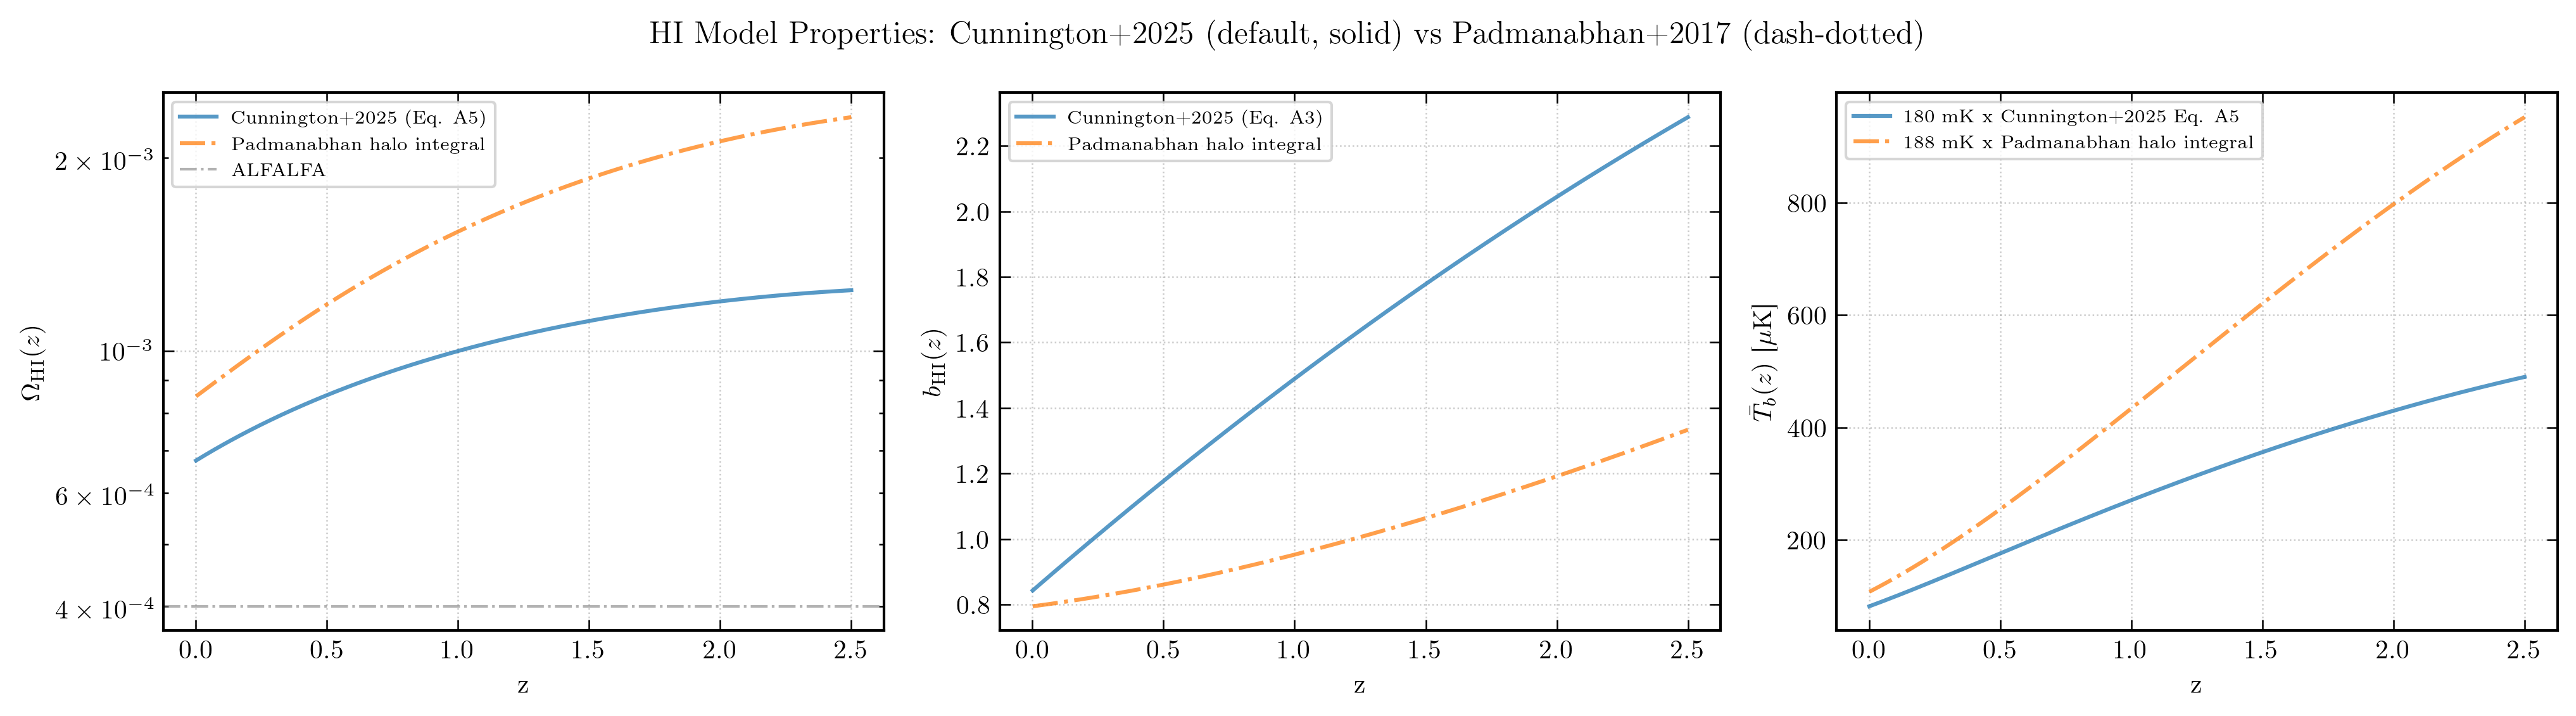

In [2]:
z_arr = np.linspace(0.001, 2.5, 300)

# Cunnington et al. (2025), arXiv:2510.27549, Eqs. A3 / A4 / A5 (MeerFish defaults)
# -- the data-calibrated polynomials used by all published MeerKLASS analyses
omega_cunn = hi.Omega_HI_cunnington(z_arr)
b_hi_cunn  = hi.b_HI_cunnington(z_arr)
Tb_cunn    = hi.T_bar_b_cunnington(z_arr)

# Padmanabhan+2017 halo integral (legacy default in the pipeline)
omega = np.array([hi.Omega_HI(z) for z in z_arr])
b_hi  = np.array([hi.b_HI(z)     for z in z_arr])
Tb    = np.array([hi.T_bar_b(z)  for z in z_arr])

fig, axes = plt.subplots(1, 3, figsize=(sty.TEXTWIDTH_IN * 1.8, sty.TEXTWIDTH_IN * 0.5))

axes[0].semilogy(z_arr, omega_cunn, **sty.FIT_STYLE,     label='Cunnington+2025 (Eq. A5)')
axes[0].semilogy(z_arr, omega,      **sty.DASHDOT_STYLE, label='Padmanabhan halo integral')
axes[0].axhline(4e-4, **sty.GUIDE_STYLE, label='ALFALFA')
axes[0].set_ylabel(r'$\Omega_{\rm HI}(z)$'); axes[0].set_xlabel('z')
axes[0].legend(fontsize=7)

axes[1].plot(z_arr, b_hi_cunn, **sty.FIT_STYLE,     label='Cunnington+2025 (Eq. A3)')
axes[1].plot(z_arr, b_hi,      **sty.DASHDOT_STYLE, label='Padmanabhan halo integral')
axes[1].set_ylabel(r'$b_{\rm HI}(z)$'); axes[1].set_xlabel('z')
axes[1].legend(fontsize=7)

axes[2].plot(z_arr, Tb_cunn * 1000, **sty.FIT_STYLE,     label='180 mK x Cunnington+2025 Eq. A5')
axes[2].plot(z_arr, Tb      * 1000, **sty.DASHDOT_STYLE, label='188 mK x Padmanabhan halo integral')
axes[2].set_ylabel(r'$\bar{T}_b(z)$ [$\mu$K]'); axes[2].set_xlabel('z')
axes[2].legend(fontsize=7)

fig.suptitle('HI Model Properties: Cunnington+2025 (default, solid) vs Padmanabhan+2017 (dash-dotted)')
fig.tight_layout()

## 2. UGRB Mean Intensity Spectrum

Total unresolved gamma-ray background from four astrophysical source classes (BL Lac, FSRQ, mAGN, SFG). GLFs use LDDE parameterizations from Ajello et al. (2012, 2014) and Di Mauro et al. (2014).

The gray band shows the Ackermann et al. (2015) IGRB measurement. The total unresolved intensity should sit within or below this band. BL Lac dominates at high energies; SFG and mAGN contribute at low energies. FSRQ is mostly resolved by Fermi-LAT.

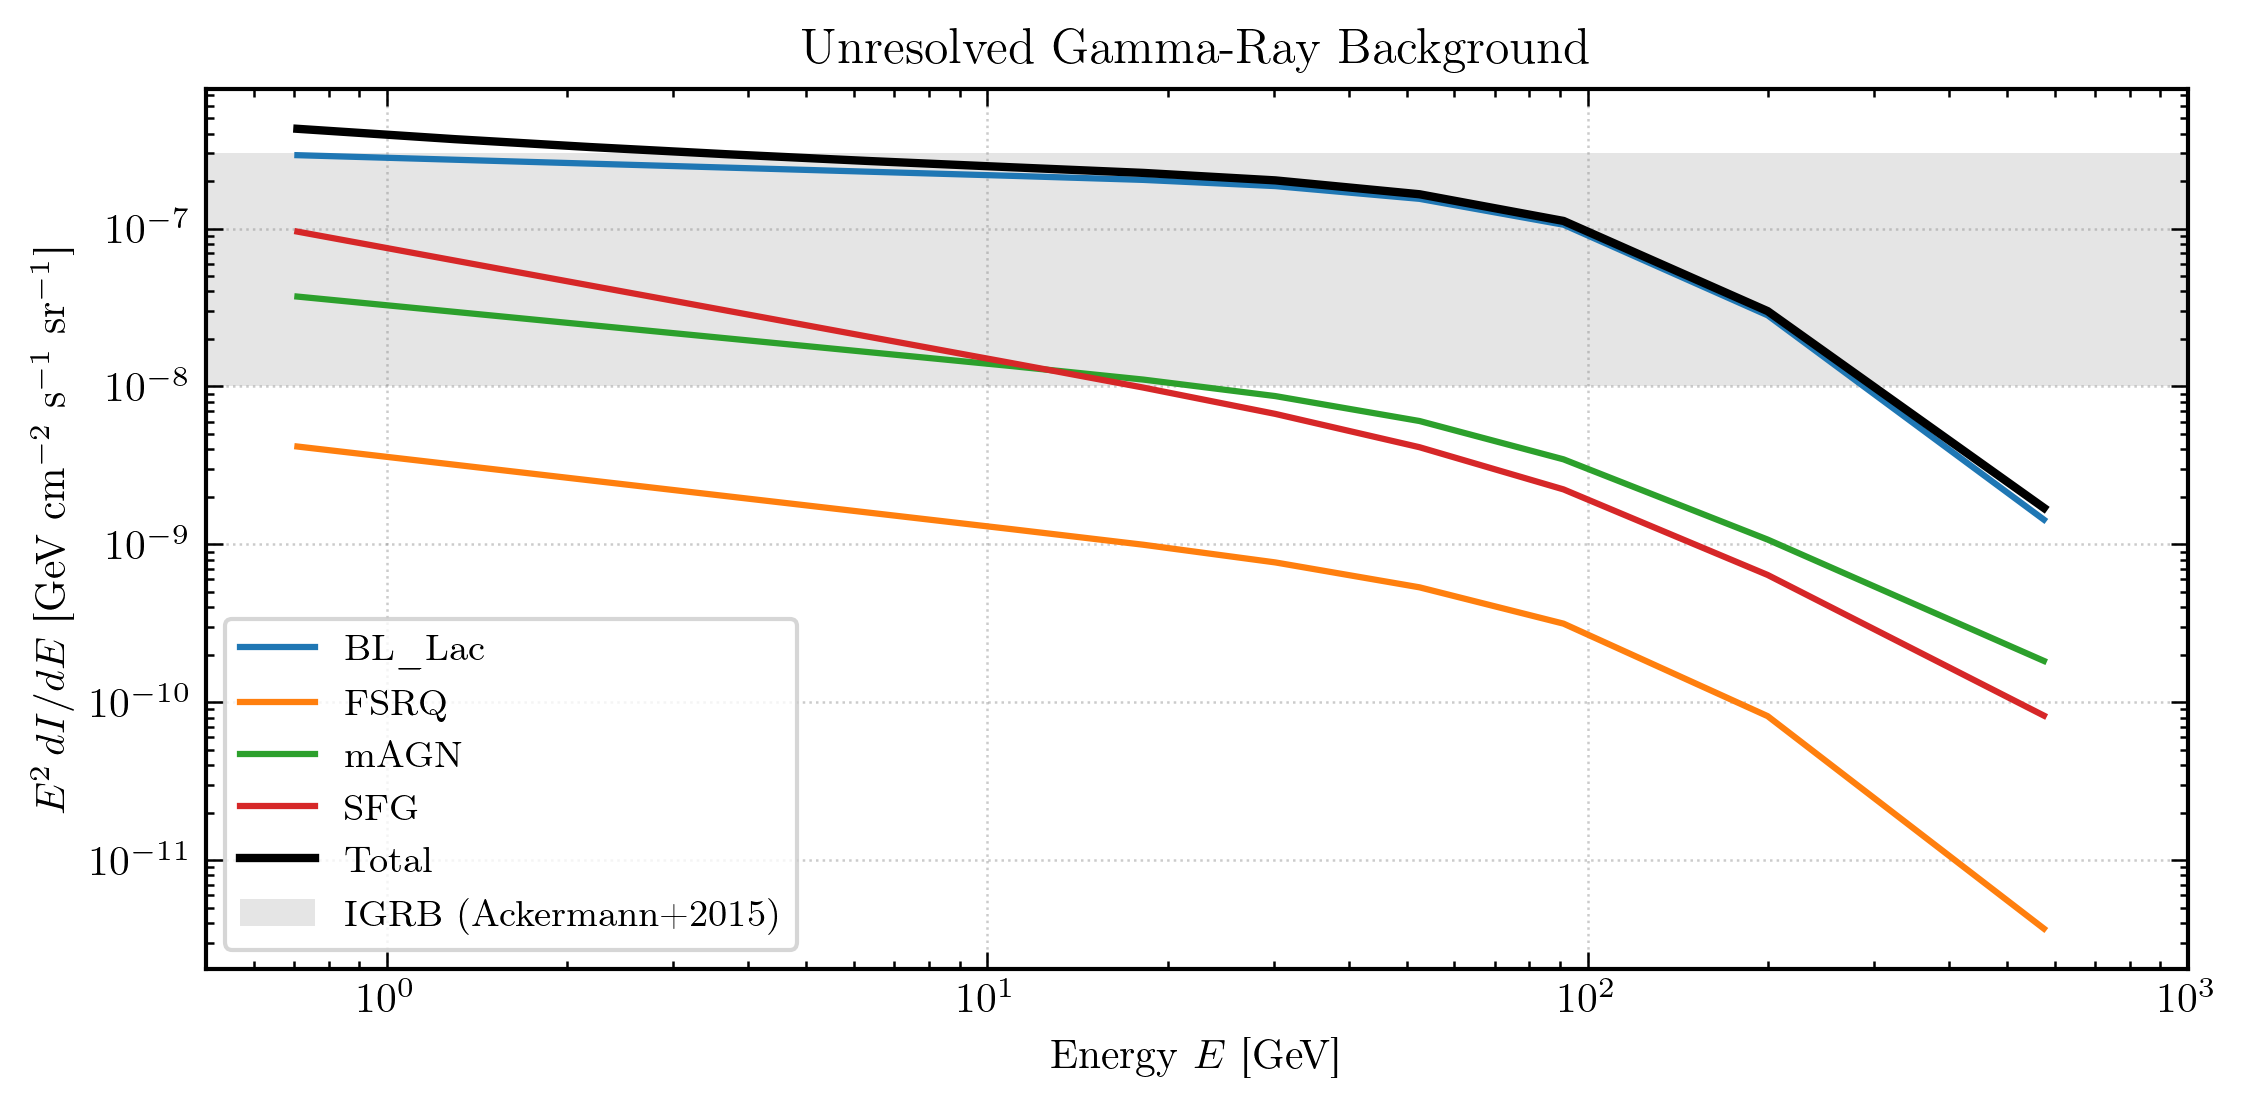

In [3]:
E_arr = cfg.FERMI_E_B
sources = ['BL_Lac', 'FSRQ', 'mAGN', 'SFG']
colors = {'BL_Lac': 'C0', 'FSRQ': 'C1', 'mAGN': 'C2', 'SFG': 'C3'}

fig, ax = sty.textwidth_figure(8)
total = np.zeros_like(E_arr)
for src in sources:
    I_arr = np.array([astro.mean_intensity(E, src) for E in E_arr])
    ax.loglog(E_arr, E_arr**2 * I_arr, label=src, color=colors[src], lw=sty.LW_STANDARD)
    total += I_arr
ax.loglog(E_arr, E_arr**2 * total, 'k-', lw=sty.LW_MEDIUM, label='Total')
ax.axhspan(1e-8, 3e-7, **sty.FILL_STYLE, color=sty.NEUTRAL_COLOR, label='IGRB (Ackermann+2015)')
ax.set_xlabel(r'Energy $E$ [GeV]')
ax.set_ylabel(r'$E^2 \, dI/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
ax.set_title('Unresolved Gamma-Ray Background')
ax.legend(); ax.set_xlim(0.5, 1000)
fig.tight_layout()

## 3. EBL Opacity & PPPC4DMID Photon Spectra

**Left:** EBL optical depth $\tau(E, z)$ from Dominguez et al. (2011) via `ebltable`. At $E < 10$ GeV the universe is transparent; at $E > 100$ GeV and $z > 0.5$ absorption is significant.

**Right:** PPPC4DMID photon yield $x^2 dN/dx$ for the $b\bar{b}$ channel at three DM masses. Tables from Cirelli et al. (2011).

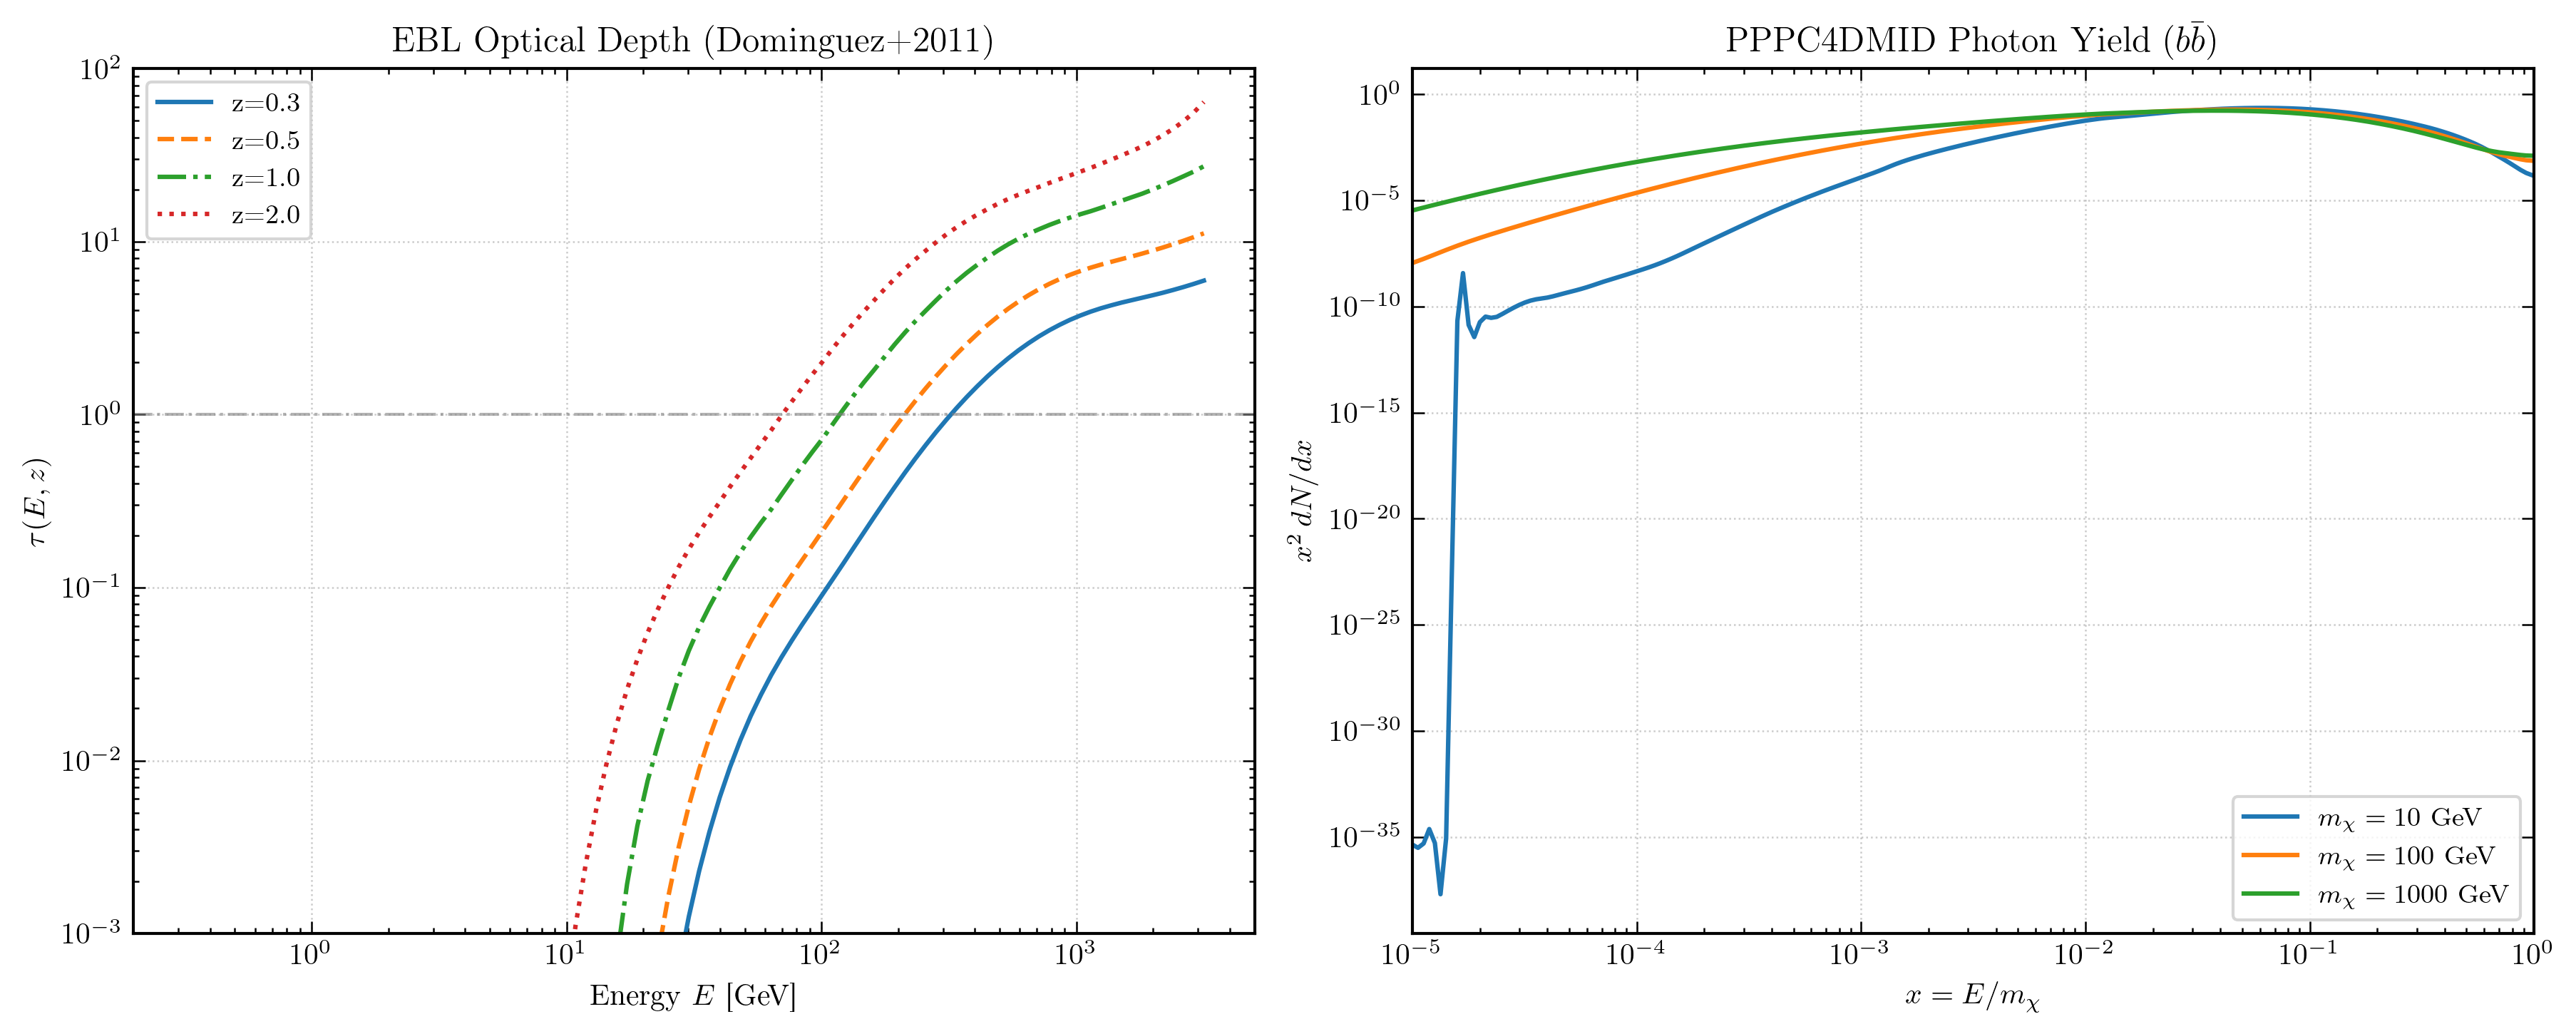

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.6, sty.TEXTWIDTH_IN * 0.65))

# EBL opacity
E_ebl = np.logspace(-0.5, 3.5, 100)
for z, ls in [(0.3, '-'), (0.5, '--'), (1.0, '-.'), (2.0, ':')]:
    ax1.semilogy(E_ebl, ebl.tau(E_ebl, z), ls=ls, lw=sty.LW_STANDARD, label=f'z={z}')
ax1.axhline(1.0, **sty.GUIDE_STYLE)
ax1.set_xlabel(r'Energy $E$ [GeV]'); ax1.set_ylabel(r'$\tau(E, z)$')
ax1.set_title('EBL Optical Depth (Dominguez+2011)')
ax1.set_xscale('log'); ax1.set_ylim(1e-3, 100); ax1.legend()

# PPPC4DMID spectra
x_arr = np.logspace(-5, -0.01, 200)
for m, color in [(10, 'C0'), (100, 'C1'), (1000, 'C2')]:
    dNdx = pppc4dmid.dNdx(x_arr, m, 'bb')
    ax2.loglog(x_arr, x_arr**2 * dNdx, color=color, lw=sty.LW_STANDARD,
               label=r'$m_\chi=' + f'{m}' + r'$ GeV')
ax2.set_xlabel(r'$x = E / m_\chi$'); ax2.set_ylabel(r'$x^2 \, dN/dx$')
ax2.set_title(r'PPPC4DMID Photon Yield ($b\bar{b}$)'); ax2.legend(); ax2.set_xlim(1e-5, 1)
fig.tight_layout()

## 4. Instrument Noise & Beam Functions

**Left:** Fermi-LAT effective noise $N^\gamma_\ell / (B^\gamma_\ell)^2$ at three energies. PSF improves at higher energy, pushing the noise wall to higher $\ell$.

**Right:** Radio effective noise for MeerKAT, SKA1, SKA2 (dish mode). SKA2's 2000 dishes dramatically reduce the noise floor.

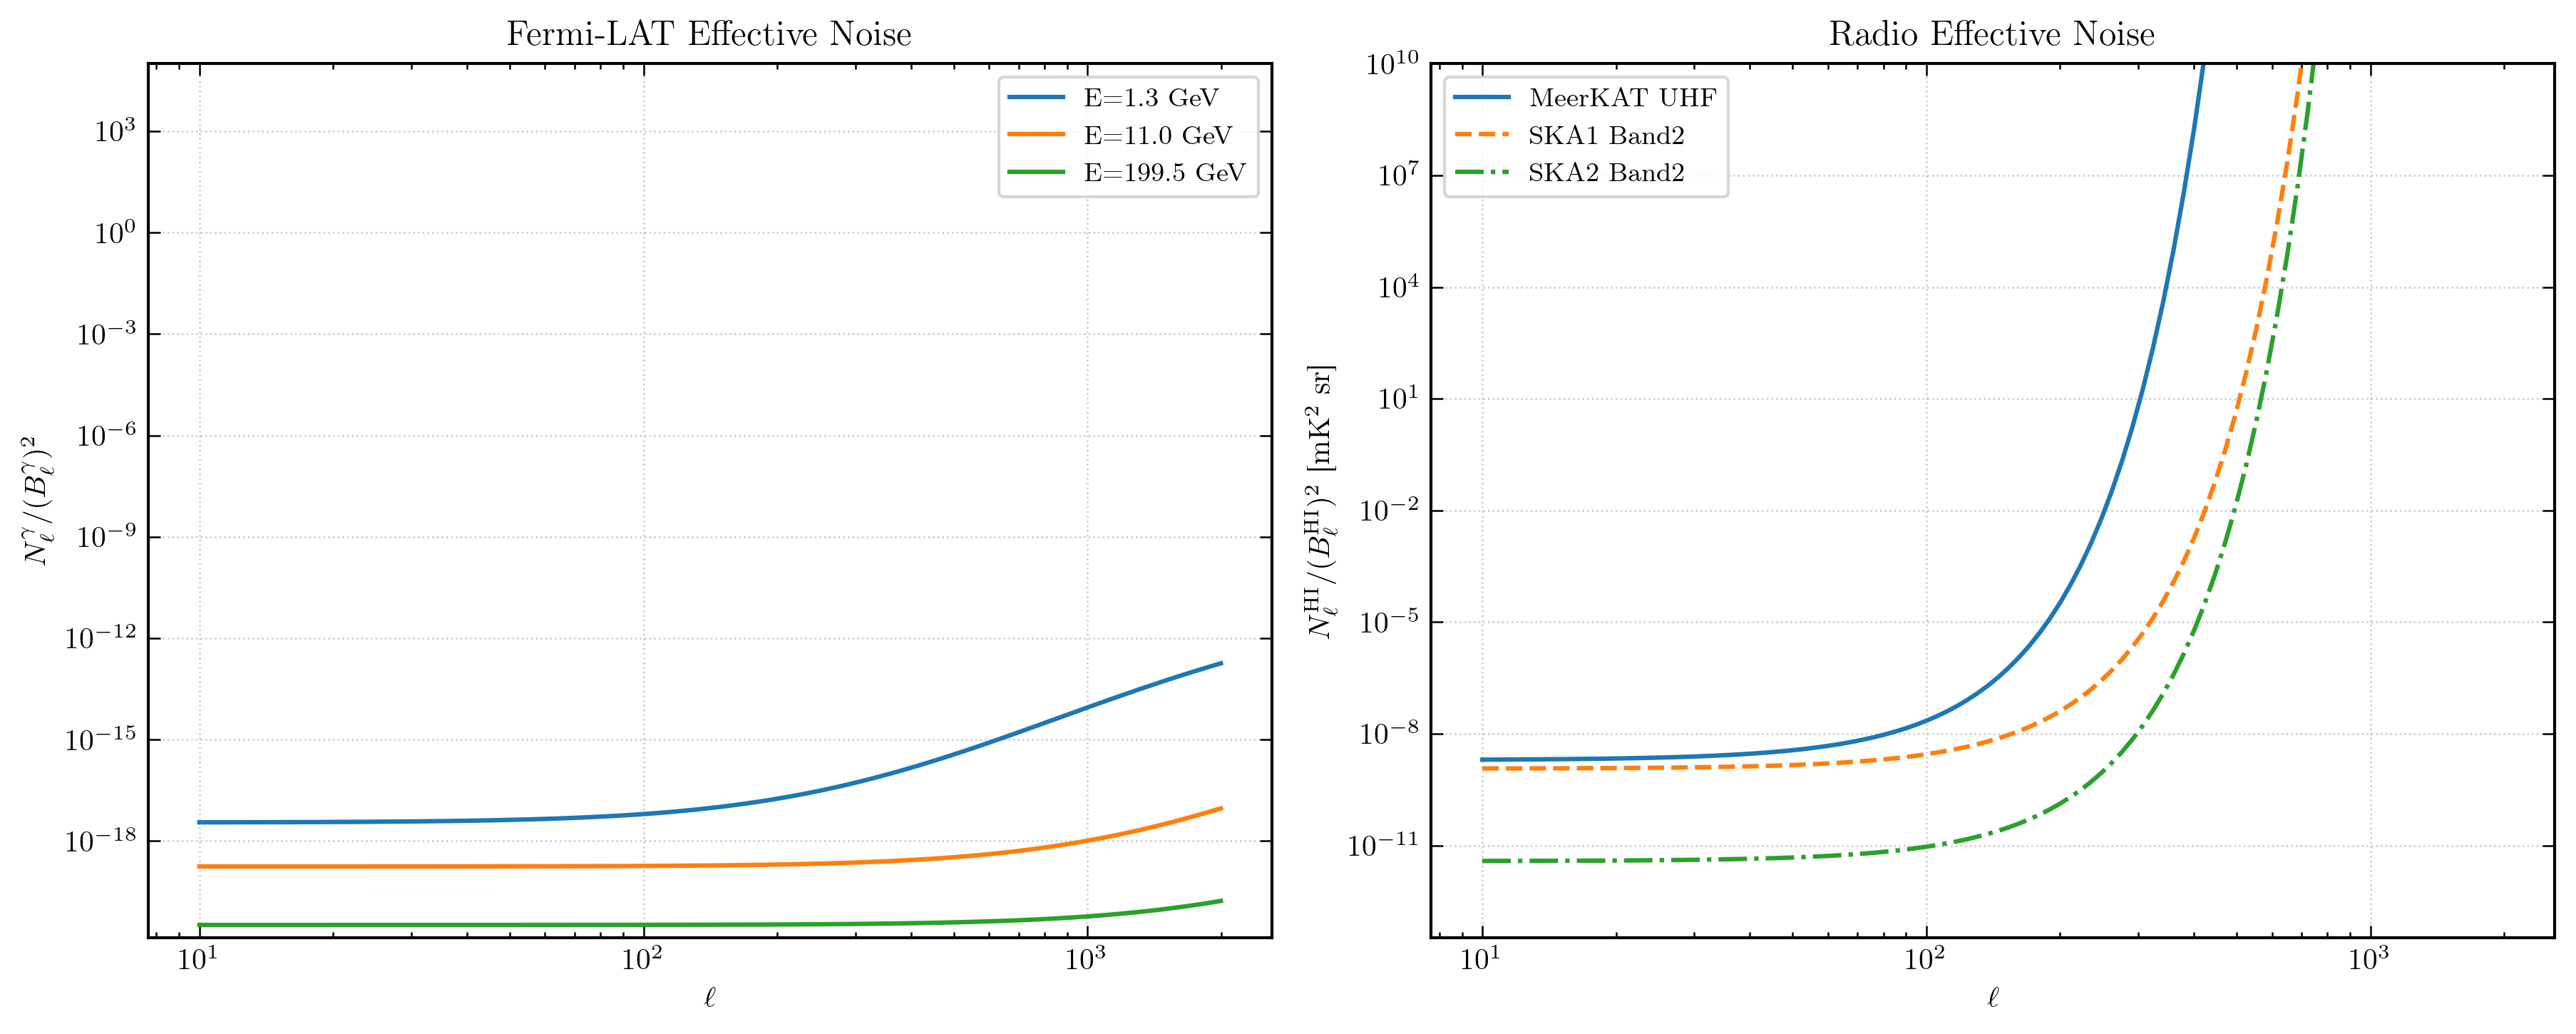

In [5]:
ell_arr = np.logspace(1, 3.3, 100)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.6, sty.TEXTWIDTH_IN * 0.65))

for ie, color in [(1, 'C0'), (5, 'C1'), (10, 'C2')]:
    E = cfg.FERMI_E_B[ie]; B = nm.beam_fermi(ell_arr, E); N = nm.noise_fermi(ie)
    y = N / np.maximum(B**2, 1e-300)
    y = np.clip(y, 0, 1e10)
    ax1.semilogy(ell_arr, y, color=color, lw=sty.LW_STANDARD, label=f'E={E:.1f} GeV')
ax1.set_xlabel(r'$\ell$'); ax1.set_ylabel(r'$N^\gamma_\ell / (B^\gamma_\ell)^2$')
ax1.set_title('Fermi-LAT Effective Noise'); ax1.legend(); ax1.set_xscale('log')
ax1.set_ylim(top=1e5)

for tel, band, color, ls in [('MeerKAT','UHF','C0','-'), ('SKA1','Band2','C1','--'), ('SKA2','Band2','C2','-.')]:
    N_r = nm.noise_radio_combined(ell_arr, tel, band)
    z_mid = 0.5 * (cfg.RADIO_TELESCOPES[tel]['bands'][band]['z_min'] +
                    cfg.RADIO_TELESCOPES[tel]['bands'][band]['z_max'])
    B_r = nm.beam_radio(ell_arr, z_mid, cfg.RADIO_TELESCOPES[tel]['d_dish_m'])
    y = N_r / np.maximum(B_r**2, 1e-300)
    y = np.clip(y, 0, 1e30)
    ax2.semilogy(ell_arr, y, color=color, ls=ls, lw=sty.LW_STANDARD, label=f'{tel} {band}')
ax2.set_xlabel(r'$\ell$')
ax2.set_ylabel(r'$N^{\rm HI}_\ell / (B^{\rm HI}_\ell)^2$ [mK$^2$ sr]')
ax2.set_title('Radio Effective Noise'); ax2.legend(); ax2.set_xscale('log')
ax2.set_ylim(top=1e10)
fig.tight_layout()

## 5. Angular Cross-Power Spectra $C_\ell$

Cross-power spectrum $\ell(\ell+1) C_\ell / 2\pi$ for MeerKAT UHF x Fermi-LAT at $E = 5$ GeV, decomposed by source class. The solid curves use the Padmanabhan HI brightness normalization from the halo-integral $\Omega_\mathrm{HI}(z)$; the dashed total uses fixed $\Omega_\mathrm{HI}=2.45\times10^{-4}$ with the same HI clustering model.

This is the core output of the Limber integration engine (`angular_power.py`). Runtime ~30s.


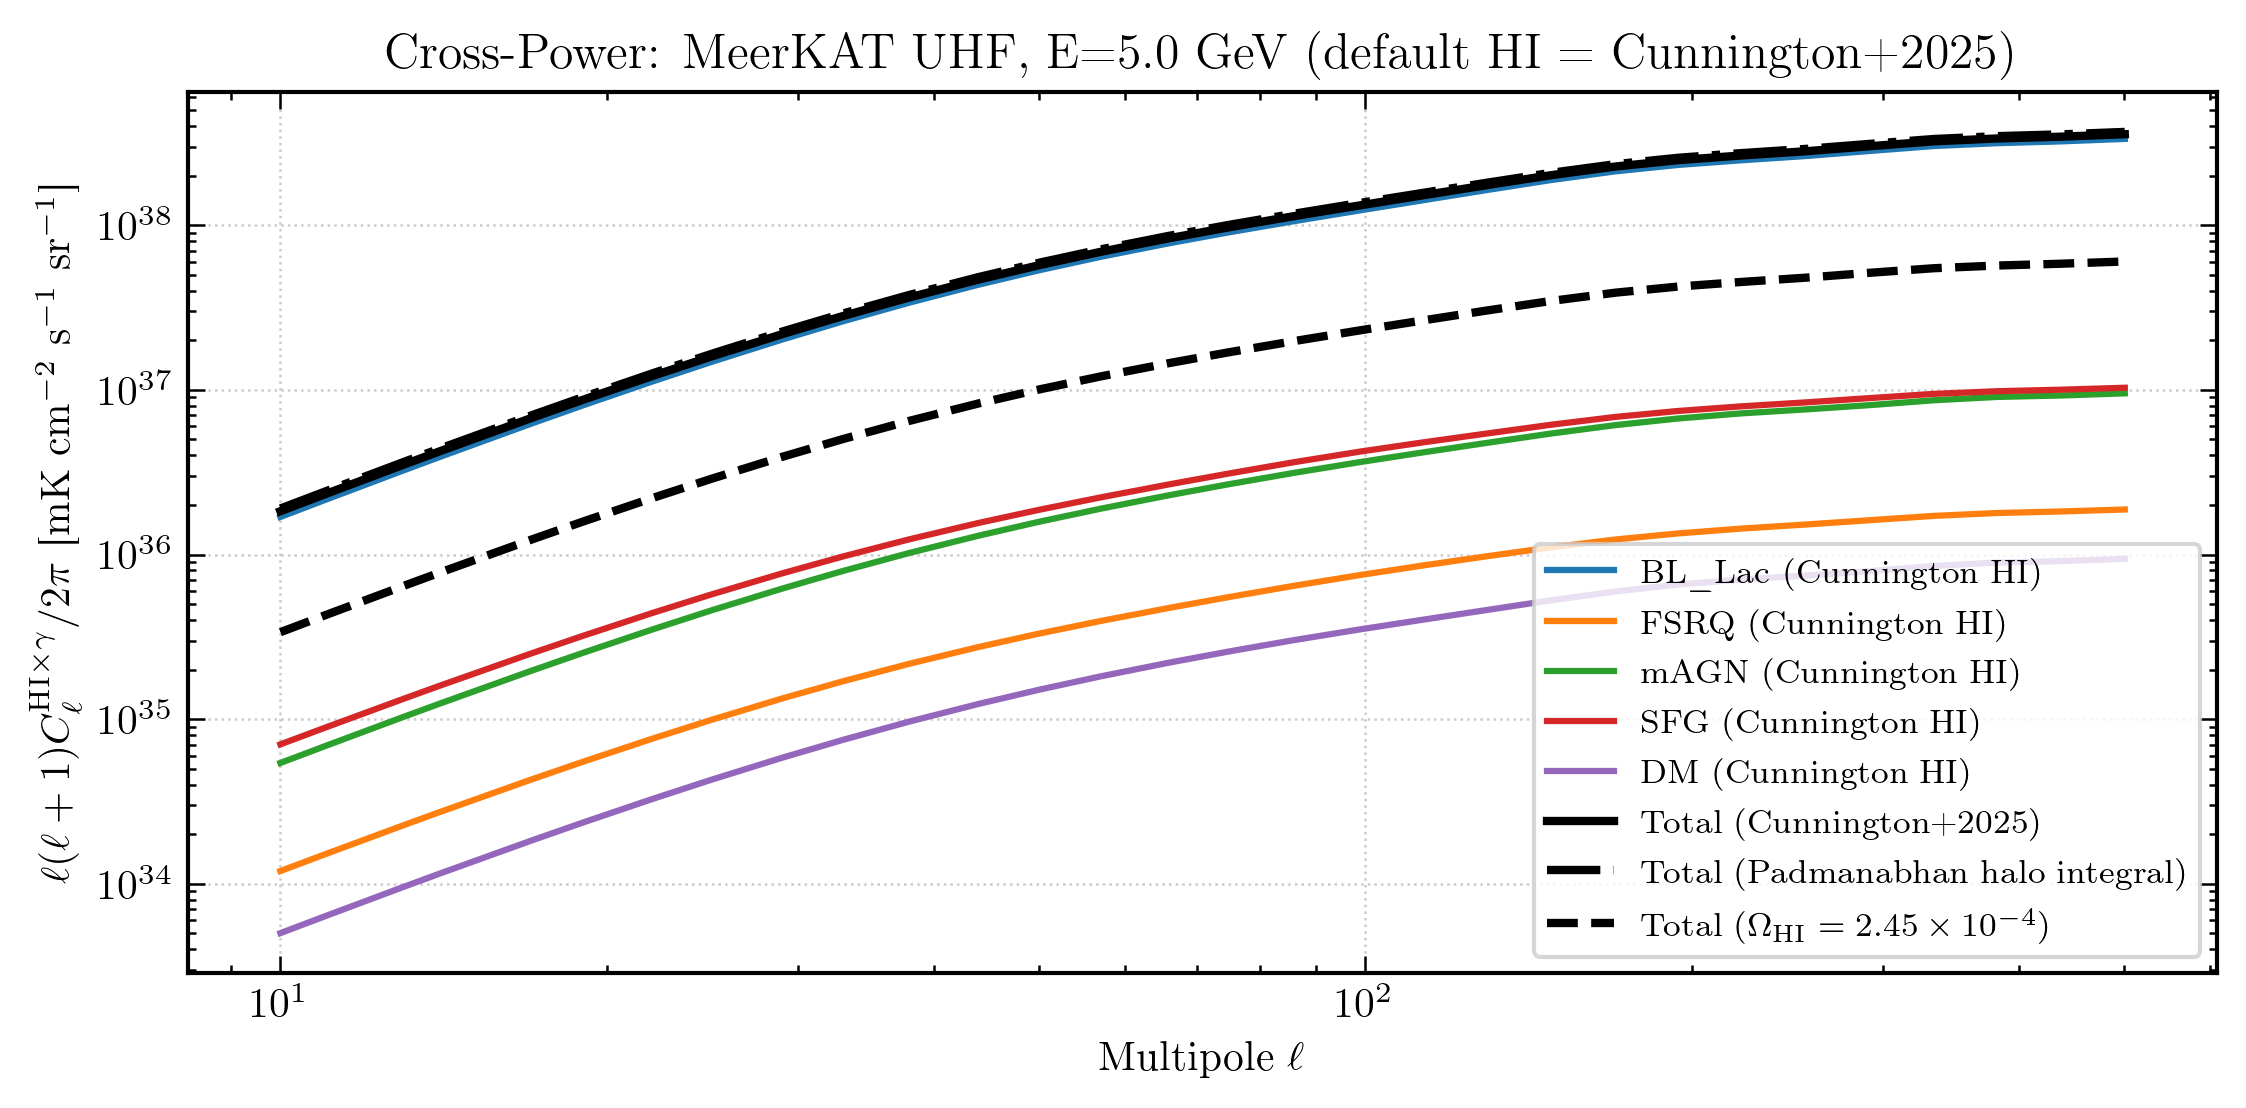

In [6]:
telescope, band, E_GeV = 'MeerKAT', 'UHF', 5.0
tel = cfg.RADIO_TELESCOPES[telescope]
z_min, z_max = tel['bands'][band]['z_min'], tel['bands'][band]['z_max']

ell_cl = np.unique(np.logspace(1, 2.7, 30).astype(int)).astype(float)

# Cunnington 2025 / MeerFish convention -- the visual default
result_cunn = ap.C_ell_HI_gamma(
    ell_cl, E_GeV, z_min, z_max, telescope, band,
    m_chi_GeV=100.0, sigma_v=cfg.SIGMA_V_THERMAL,
    include_DM=True, n_z=300, n_k_M=15,
    hi_brightness='cunnington'
)
result_padma = ap.C_ell_HI_gamma(
    ell_cl, E_GeV, z_min, z_max, telescope, band,
    m_chi_GeV=100.0, sigma_v=cfg.SIGMA_V_THERMAL,
    include_DM=True, n_z=300, n_k_M=15,
    hi_brightness='padmanabhan'
)
result_fixed = ap.C_ell_HI_gamma(
    ell_cl, E_GeV, z_min, z_max, telescope, band,
    m_chi_GeV=100.0, sigma_v=cfg.SIGMA_V_THERMAL,
    include_DM=True, n_z=300, n_k_M=15,
    hi_brightness='fixed_omega'
)

fig, ax = sty.textwidth_figure(8)
colors = {'BL_Lac': 'C0', 'FSRQ': 'C1', 'mAGN': 'C2', 'SFG': 'C3', 'DM': 'C4'}
# Per-source-class breakdown uses the default Cunnington 2025 normalization
for key in ['BL_Lac', 'FSRQ', 'mAGN', 'SFG', 'DM']:
    if key in result_cunn:
        C = result_cunn[key]; nz = np.abs(C) > 0
        if np.any(nz):
            ax.loglog(ell_cl[nz], ell_cl[nz]*(ell_cl[nz]+1)*np.abs(C[nz])/(2*np.pi),
                      label=f'{key} (Cunnington HI)', color=colors.get(key), lw=sty.LW_STANDARD)

for label, result, ls in [('Total (Cunnington+2025)', result_cunn, '-'),
                          ('Total (Padmanabhan halo integral)', result_padma, '-.'),
                          (r'Total ($\Omega_{\rm HI}=2.45\times10^{-4}$)', result_fixed, '--')]:
    C_tot = result['total']; nz = np.abs(C_tot) > 0
    if np.any(nz):
        ax.loglog(ell_cl[nz], ell_cl[nz]*(ell_cl[nz]+1)*np.abs(C_tot[nz])/(2*np.pi),
                  color='k', ls=ls, lw=sty.LW_MEDIUM, label=label)

ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1) C_\ell^{\rm HI\times\gamma} / 2\pi$ [mK cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
ax.set_title(f'Cross-Power: {telescope} {band}, E={E_GeV} GeV (default HI = Cunnington+2025)')
ax.legend(fontsize=8)
fig.tight_layout()

## 6a. Normalized Window Functions -- Survey-Independent (Theoretical)

Intrinsic (survey-independent) window functions $W_i(z) / \langle I_i \rangle$ at $E = 5$ GeV. No instrument selection applied:
- **HI (solid C4, default):** Cunnington et al. (2025) Eqs. A4/A5: $\bar{T}_b(z) = 180\,h\,\Omega_\mathrm{HI}^\mathrm{C25}(z)\,(1+z)^2/E(z)$ mK with the MeerFish polynomial $\Omega_\mathrm{HI}^\mathrm{C25}(z) = 6.7432\!\times\!10^{-4} + 3.9\!\times\!10^{-4} z - 6.5\!\times\!10^{-5} z^2$. The convention used by every published MeerKLASS analysis and by the public MeerFish Fisher code.
- **HI (dashed C4):** Pinetti (2022) $\bar{T}_b(z) = 44\,\mu$K$\,(1+z)^2/E(z)$ (fixed $\Omega_\mathrm{HI} = 2.45\times10^{-4}$, Battye+2013 form).
- **HI (dash-dotted C4):** Pipeline halo-integral $\bar{T}_b(z) = 188\,h\,\Omega_\mathrm{HI}(z)\,(1+z)^2/E(z)$ mK (Padmanabhan+2017 modified-NFW model). Internally consistent with the halo-model clustering branch but over-predicts the absolute amplitude relative to the MeerKLASS data.
- **Astro sources:** Total emission integrated over $[L_\mathrm{min}, L_\mathrm{max}]$ (no Fermi sensitivity cut)
- **DM:** Intrinsic annihilation kernel ($m_\chi = 100$ GeV, $b\bar{b}$, thermal relic)

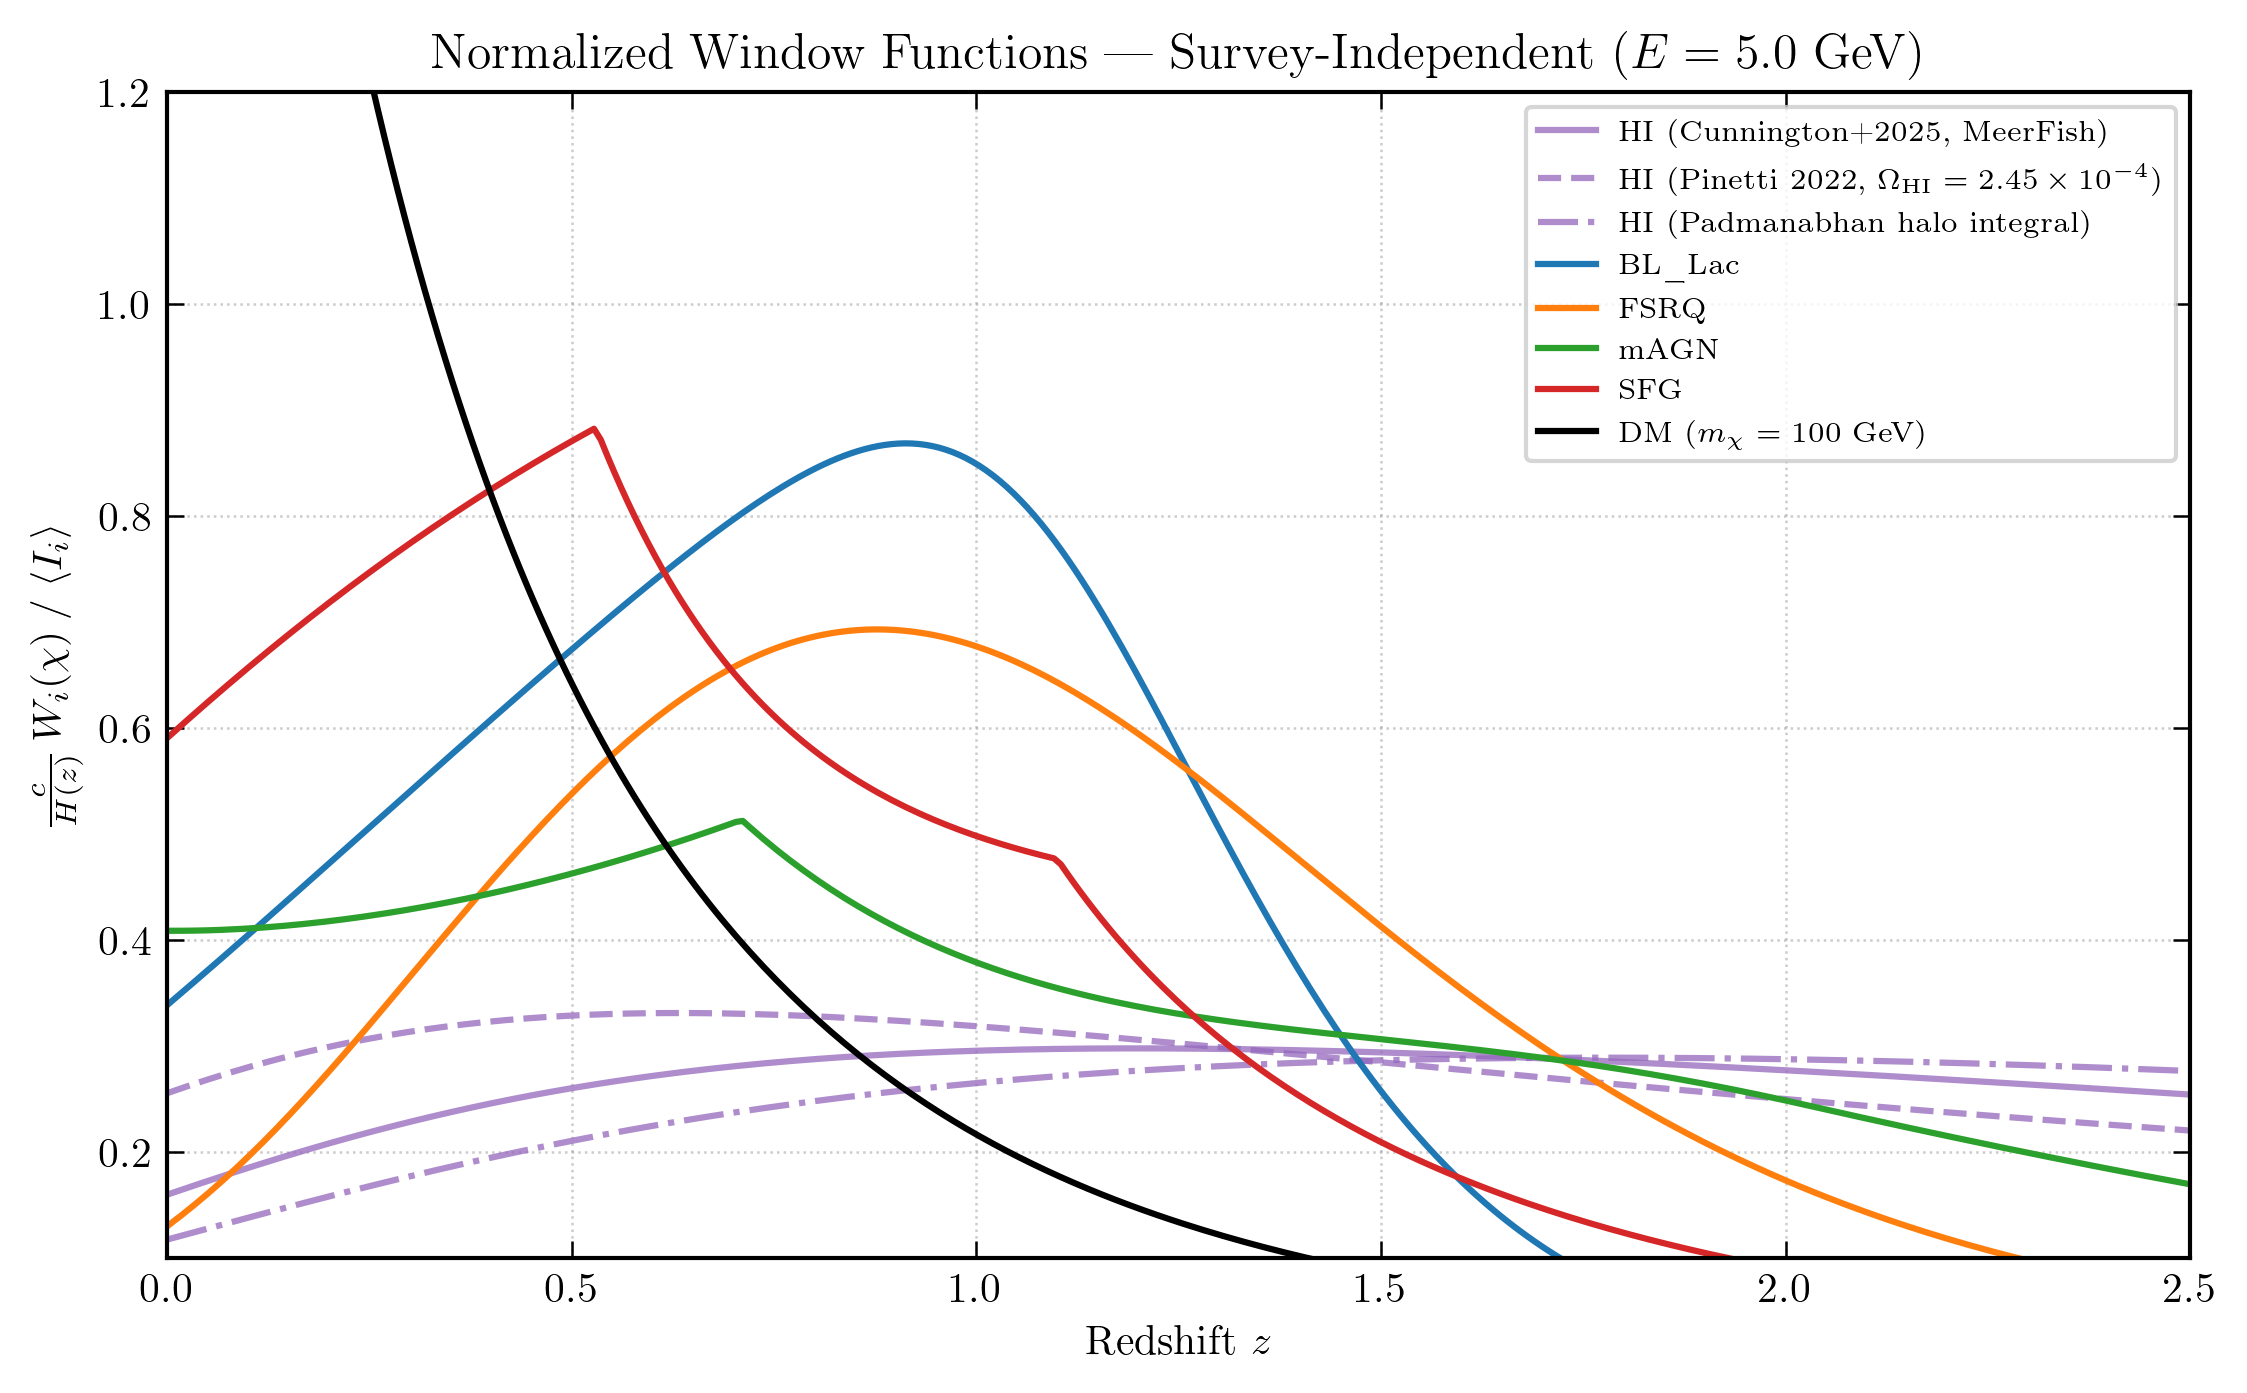

In [7]:
E_ref, m_chi = 5.0, 100.0
z_plot = np.linspace(0.001, 2.5, 300)

from hi_gamma_xcorr import pinetti2022 as p22
from hi_gamma_xcorr.angular_power import _Z_NORM_MAX, _N_Z_NORM

# Extended grid for normalization integral [0, z_norm_max]
z_ext = np.linspace(0.001, _Z_NORM_MAX, _N_Z_NORM)
dz_ext = z_ext[1] - z_ext[0]
c_h_over_H_ext = np.array([cfg.C_LIGHT_KM_S * cfg.h / cosmo.H(z) for z in z_ext])
c_h_over_H = np.array([cfg.C_LIGHT_KM_S * cfg.h / cosmo.H(z) for z in z_plot])

# HI: Cunnington 2025 Eq. A4/A5 -- DEFAULT, normalize over [0, z_norm_max]
W_hi_cunn = hi.T_bar_b_cunnington(z_plot) * c_h_over_H
W_hi_cunn_ext = hi.T_bar_b_cunnington(z_ext) * c_h_over_H_ext
W_hi_cunn_norm = W_hi_cunn / (np.sum(W_hi_cunn_ext) * dz_ext)

# HI: Padmanabhan halo integral (legacy)
W_hi_padma = np.array([hi.T_bar_b(z) for z in z_plot]) * c_h_over_H
W_hi_padma_ext = np.array([hi.T_bar_b(z) for z in z_ext]) * c_h_over_H_ext
W_hi_padma_norm = W_hi_padma / (np.sum(W_hi_padma_ext) * dz_ext)

# HI: Pinetti 2022 (fixed Omega_HI = 2.45e-4)
W_hi_pinetti = np.array([p22.T_bar_b_thesis(z) for z in z_plot]) * c_h_over_H
W_hi_pinetti_ext = np.array([p22.T_bar_b_thesis(z) for z in z_ext]) * c_h_over_H_ext
W_hi_pinetti_norm = W_hi_pinetti / (np.sum(W_hi_pinetti_ext) * dz_ext)

# Astro + DM via normalized_windows (uses the pipeline's default HI brightness internally;
# only the HI window itself depends on hi_brightness, so this is unchanged)
W_norm = ap.normalized_windows(z_plot, E_GeV=E_ref, m_chi_GeV=m_chi,
                               unresolved_only=False, include_DM=True)

fig, ax = sty.textwidth_figure(10)
ax.plot(z_plot, W_hi_cunn_norm,    color='C4', **sty.FIT_STYLE,
        label='HI (Cunnington+2025, MeerFish)')
ax.plot(z_plot, W_hi_pinetti_norm, color='C4', **sty.MODEL_STYLE,
        label=r'HI (Pinetti 2022, $\Omega_{\rm HI}=2.45\times10^{-4}$)')
ax.plot(z_plot, W_hi_padma_norm,   color='C4', **sty.DASHDOT_STYLE,
        label='HI (Padmanabhan halo integral)')
for src, color in [('BL_Lac', 'C0'), ('FSRQ', 'C1'), ('mAGN', 'C2'), ('SFG', 'C3')]:
    ax.plot(z_plot, W_norm[src], color=color, lw=sty.LW_STANDARD, label=src)
ax.plot(z_plot, W_norm['DM'], color='k', lw=sty.LW_STANDARD,
        label=r'DM ($m_\chi=' + f'{m_chi:.0f}' + r'$ GeV)')

ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\frac{c}{H(z)}\,W_i(\chi)\;/\;\langle I_i \rangle$')
ax.set_title(r'Normalized Window Functions --- Survey-Independent ($E = ' + f'{E_ref}' + r'$ GeV)')
ax.legend(fontsize=7); ax.set_xlim(0.0, 2.5); ax.set_ylim(0.1, 1.2)
fig.tight_layout()

## 6b. Normalized Window Functions -- Survey-Dependent (Fermi-LAT Forecast)

Observable window functions for Fermi-LAT forecast mode:
- **HI (solid C4, default):** Cunnington et al. (2025) MeerFish 180 mK + Eq. A5 polynomial $\Omega_\mathrm{HI}(z)$
- **HI (dashed C4):** Pinetti (2022) fixed $\Omega_\mathrm{HI} = 2.45\times10^{-4}$ (no band selection)
- **HI (dash-dotted C4):** Pipeline halo-integral Padmanabhan+2017 (no band selection)
- **Astro sources:** Unresolved only (Fermi-LAT $F_\mathrm{sens} = 10^{-10}$ cm$^{-2}$ s$^{-1}$ threshold applied)
- **DM:** Same as theoretical (no survey dependence)

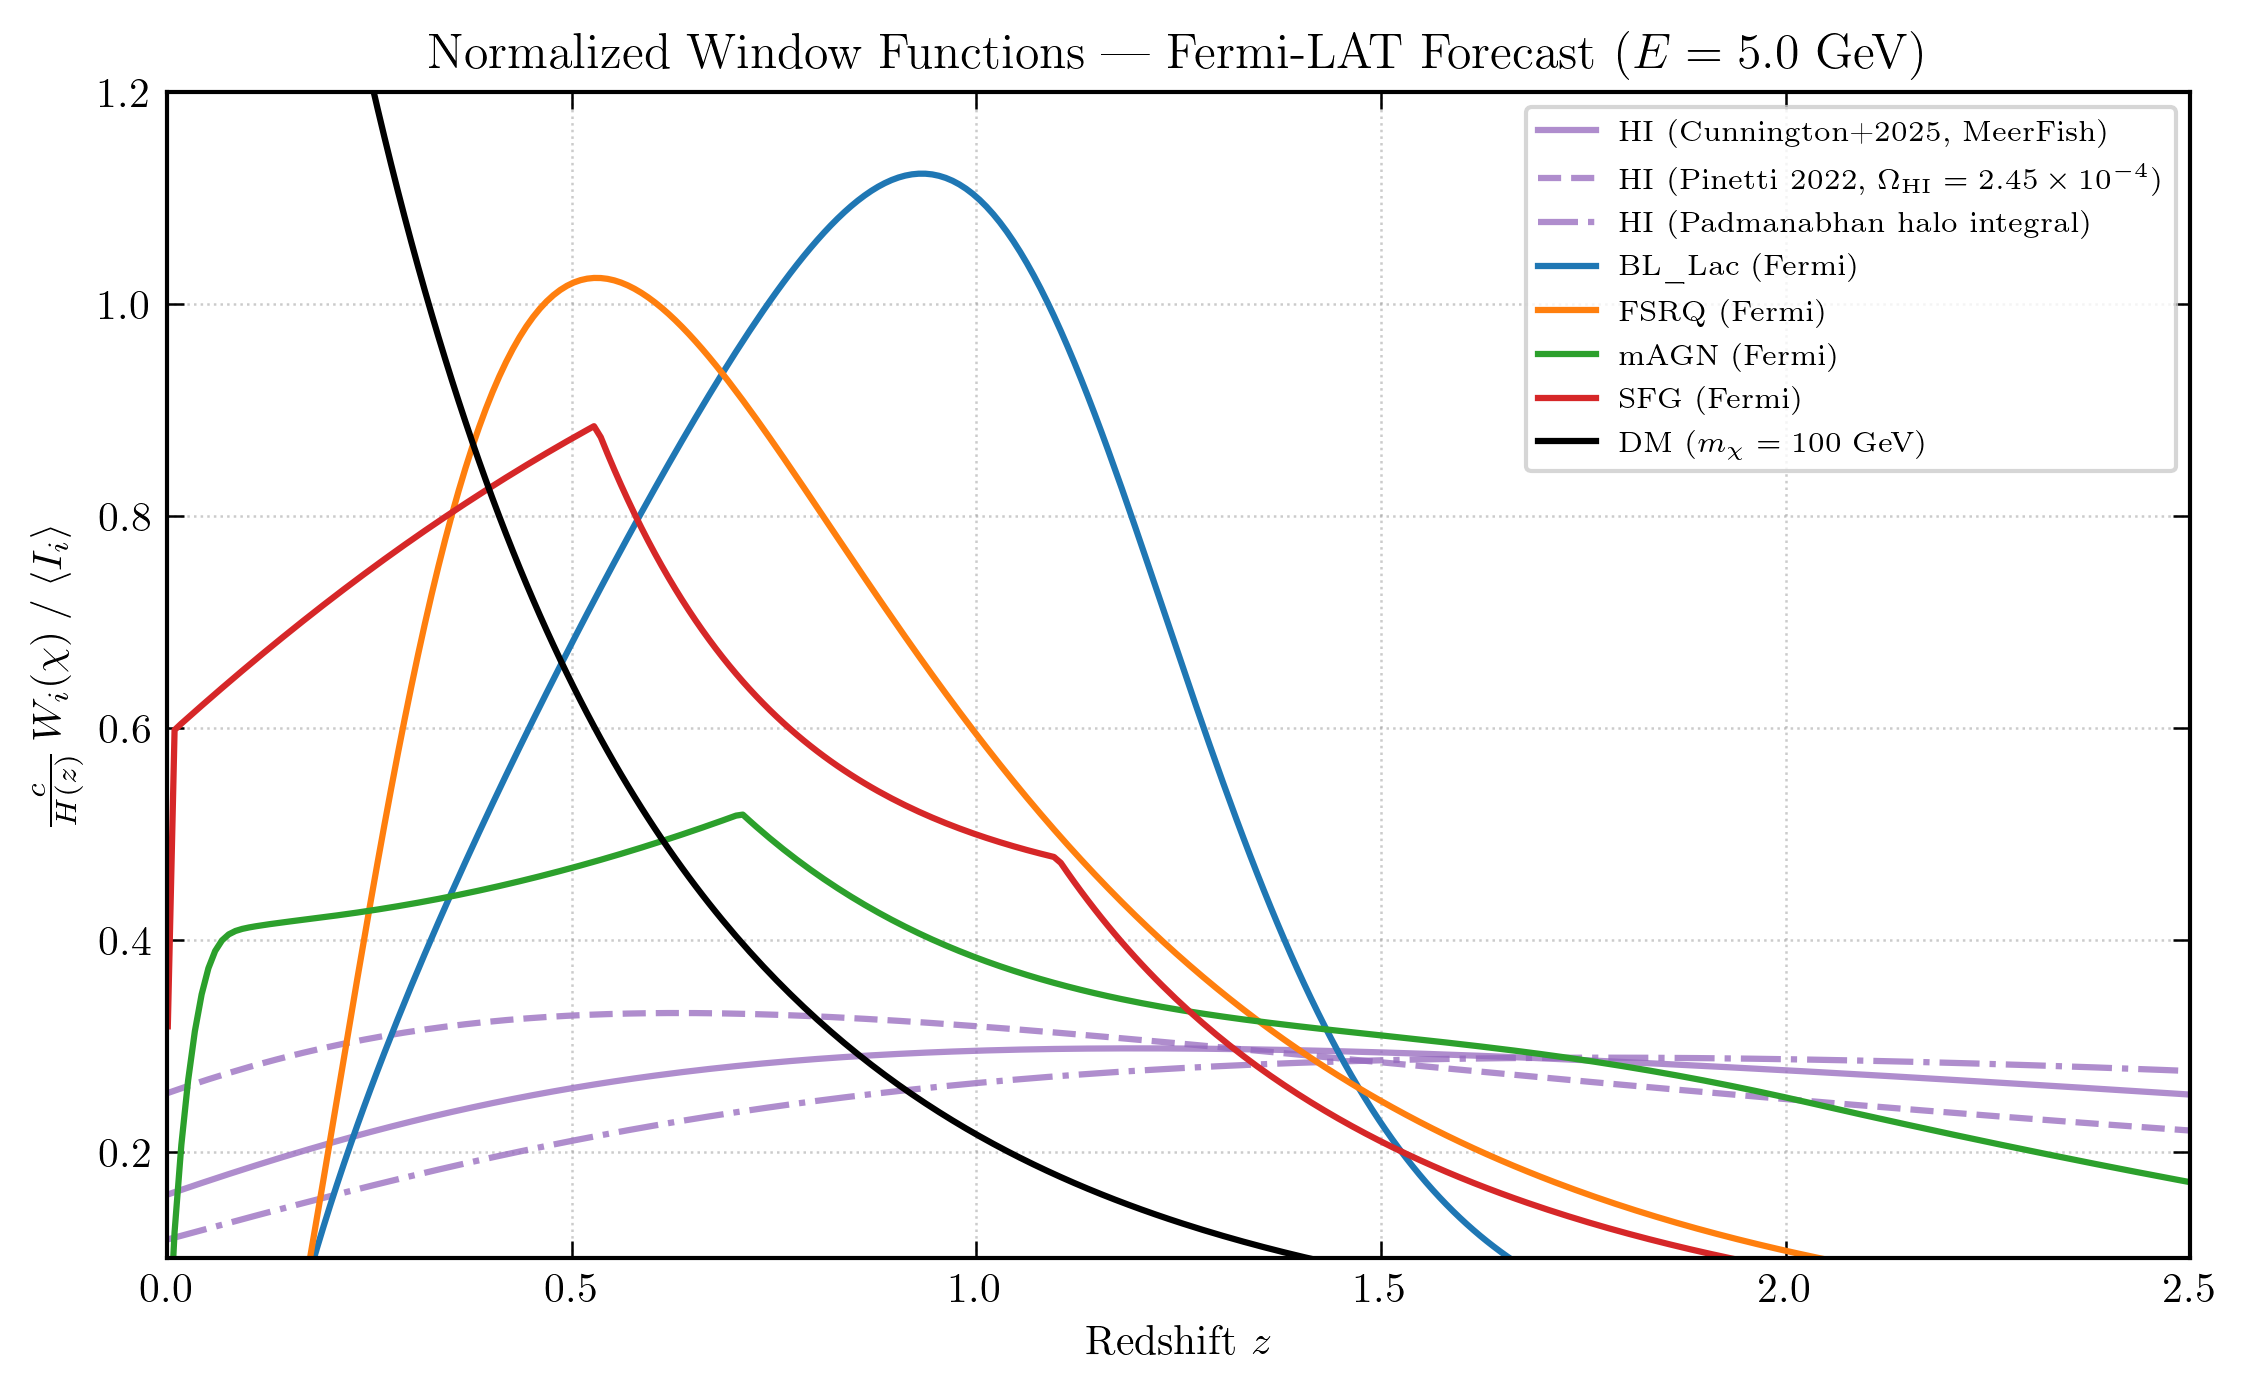

In [8]:
z_plot2 = np.linspace(0.001, 2.5, 300)
c_h_over_H2 = np.array([cfg.C_LIGHT_KM_S * cfg.h / cosmo.H(z) for z in z_plot2])

# HI: Cunnington 2025 -- DEFAULT (normalised over the same extended grid as 6a)
W_hi_cunn2 = hi.T_bar_b_cunnington(z_plot2) * c_h_over_H2
W_hi_cunn2_norm = W_hi_cunn2 / (np.sum(W_hi_cunn_ext) * dz_ext)

# HI: Padmanabhan halo integral
W_hi_padma2 = np.array([hi.T_bar_b(z) for z in z_plot2]) * c_h_over_H2
W_hi_padma2_norm = W_hi_padma2 / (np.sum(W_hi_padma_ext) * dz_ext)

# HI: Pinetti 2022 fixed Omega_HI
W_hi_pin2 = np.array([p22.T_bar_b_thesis(z) for z in z_plot2]) * c_h_over_H2
W_hi_pin2_norm = W_hi_pin2 / (np.sum(W_hi_pinetti_ext) * dz_ext)

W_survey = ap.normalized_windows(z_plot2, E_GeV=E_ref, m_chi_GeV=m_chi,
                                 unresolved_only=True, include_DM=True)

fig, ax = sty.textwidth_figure(10)
ax.plot(z_plot2, W_hi_cunn2_norm,  color='C4', **sty.FIT_STYLE,
        label='HI (Cunnington+2025, MeerFish)')
ax.plot(z_plot2, W_hi_pin2_norm,   color='C4', **sty.MODEL_STYLE,
        label=r'HI (Pinetti 2022, $\Omega_{\rm HI}=2.45\times10^{-4}$)')
ax.plot(z_plot2, W_hi_padma2_norm, color='C4', **sty.DASHDOT_STYLE,
        label='HI (Padmanabhan halo integral)')
for src, color in [('BL_Lac', 'C0'), ('FSRQ', 'C1'), ('mAGN', 'C2'), ('SFG', 'C3')]:
    ax.plot(z_plot2, W_survey[src], color=color, lw=sty.LW_STANDARD, label=src + ' (Fermi)')
ax.plot(z_plot2, W_survey['DM'], color='k', lw=sty.LW_STANDARD,
        label=r'DM ($m_\chi=' + f'{m_chi:.0f}' + r'$ GeV)')

ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\frac{c}{H(z)}\,W_i(\chi)\;/\;\langle I_i \rangle$')
ax.set_title(r'Normalized Window Functions --- Fermi-LAT Forecast ($E = ' + f'{E_ref}' + r'$ GeV)')
ax.legend(loc='upper right', fontsize=7); ax.set_xlim(0.0, 2.5); ax.set_ylim(0.1, 1.2)
fig.tight_layout()

## 7. SNR Forecast Table (Pinetti et al. Table 4)

Signal-to-noise ratio for detecting the HI x gamma-ray cross-correlation, compared to Pinetti et al. (2020) Table 4 targets (red stars). Uses all 12 Fermi energy bins summed over $\ell = 10$-$500$.

### Canonical convention per entry

Each entry now uses its **canonical** $T_\mathrm{sys}$ and $\Omega_\mathrm{HI}$ models, set per-telescope in `cfg.RADIO_TELESCOPES[telescope]`:

**Pinetti+(2020/2022) legacy forecast targets** (`MeerKAT`, `SKA1`, `SKA2`) ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ orange bars:
- $T_\mathrm{sys}$ model: **`'pinetti'`** = generic radio formula $T_\mathrm{sys} = 30\,\mathrm{K} + 60\,\mathrm{K}\,(300\,\mathrm{MHz}/\nu)^{2.55}$ (Pinetti+2020 Eq. 3.18, originally Camera et al. 2013, arXiv:1305.6928). At L-band cosmology gives $\sim 32\,\mathrm{K}$, at UHF cosmology gives $\sim 35\,\mathrm{K}$.
- $\Omega_\mathrm{HI}$ model: **`'fixed_omega'`** = $\Omega_\mathrm{HI} = 2.45\times 10^{-4}$ (Pinetti+2020 / Battye+2013), with the 188 mK prefactor.
- $F_\mathrm{sens}$ (unresolved-source threshold): **`'pinetti_constant'`** = $1\times 10^{-10}$ cm$^{-2}$ s$^{-1}$ constant (Pinetti+2020 ﷿﷿﷿﷿﷿﷿3.2). Conservative ~early-Fermi 1FGL/2FGL completeness limit. The 11-bin energy scheme + per-bin $(\ell_\mathrm{min}, \ell_\mathrm{max})$ + King-PSF beam window come from Ammazzalorso, Fornengo, Horiuchi & Regis (2018), [arXiv:1808.09225](https://arxiv.org/abs/1808.09225) (see `docs/literature/ammazzalorso2018b_fermi_2mpz.md`).
- Rationale: apples-to-apples comparison against Pinetti+2020 Table 4 red stars, using Pinetti's exact $T_\mathrm{sys}$ + $\Omega_\mathrm{HI}$ + $F_\mathrm{sens}$ assumptions; the gamma-ray binning + beam treatment from 1808.09225 is the most data-grade Fermi-LAT setup that Pinetti's analysis is built on.

**MeerKLASS HI single-dish forecasts** (`MeerKLASS_L_pilot`, `MeerKLASS_L_deepfield`, `MeerKLASS_2024_HI`, `MeerKLASS_XLP_2028`, `MeerKLASS_DR1_L`, `MeerKLASS_DR1_UHF`) ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ steelblue bars:
- $T_\mathrm{sys}$ model: **`'meerkat'`** = canonical MeerKAT receiver model from MeerKLASS Collaboration (2025) Eqs. 21-22 (citing Wang et al. 2021 / Cunnington 2022), $T_\mathrm{sys}(\nu) = T_\mathrm{rx}(\nu) + T_\mathrm{spl} + T_\mathrm{CMB} + T_\mathrm{gal}(\nu)$ with $T_\mathrm{rx} = 7.5\,\mathrm{K} + 10\,\mathrm{K}\,(\nu/\mathrm{GHz} - 0.75)^2$, $T_\mathrm{spl} = 3$ K, $T_\mathrm{gal}(\nu) = 25\,\mathrm{K}\,(408\,\mathrm{MHz}/\nu)^{2.75}$. Gives $\sim 16\,\mathrm{K}$ at L-band cosmology and $\sim 17\,\mathrm{K}$ at UHF cosmology ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ about half the Pinetti generic value, so the MeerKLASS noise is $\sim 4\times$ smaller per mode.
- $\Omega_\mathrm{HI}$ model: **`'cunnington'`** = Cunnington et al. (2025), arXiv:2510.27549, Eq. A5 polynomial $\Omega_\mathrm{HI}(z) = 6.7432\times 10^{-4} + 3.9\times 10^{-4}\,z - 6.5\times 10^{-5}\,z^2$ with the 180 mK prefactor (Battye+2013 / MeerFish convention). The HI bias also switches to the matched Eq. A3 polynomial $b_\mathrm{HI}(z) = 0.842 + 0.693\,z - 0.0459\,z^2$ for self-consistency.
- $F_\mathrm{sens}$ (unresolved-source threshold): **`'4fgl_dr4_psf'`** = baseline $7.3\times 10^{-11}$ photon cm$^{-2}$ s$^{-1}$ in 1-100 GeV (source-class average), converted from the directly-quoted $1\times 10^{-12}$ erg cm$^{-2}$ s$^{-1}$ in 100 MeV-100 GeV reported by Ballet et al. (2023), [arXiv:2307.12546](https://arxiv.org/abs/2307.12546) ﷿﷿﷿﷿﷿﷿5 ﷿﷿﷿﷿﷿﷿﷿﷿﷿ the **Fermi-LAT 4FGL-DR4** 14-year catalogue. See `docs/literature/ballet2023_4fgl_dr4.md`. The per-energy PSF-area scaling $F_\mathrm{sens}(E) = F_\mathrm{baseline}\cdot[\sigma_0(E)/\sigma_0(E_\mathrm{ref})]^2$ from Ammazzalorso, Fornengo, Horiuchi & Regis (2018), [arXiv:1808.09225](https://arxiv.org/abs/1808.09225) ﷿﷿﷿﷿﷿﷿II.A is applied on top. The same 11-bin energy scheme + per-bin $(\ell_\mathrm{min}, \ell_\mathrm{max})$ + King-PSF beam window from 1808.09225 is shared with the Pinetti mode. ~0.73﷿﷿﷿﷿﷿﷿ Pinetti's threshold (NOT 25﷿﷿﷿﷿﷿﷿ lower as a naive erg-vs-photon comparison would suggest); a small ~5-10% SNR shift, dominated by the per-energy PSF scaling tightening at low energies.
- Rationale: actually-measured MeerKAT receiver performance + data-anchored HI density polynomial used by all published MeerKLASS analyses and the public `MeerFish` Fisher code; actually-measured Fermi-LAT 4FGL-DR4 catalogue completeness for the unresolved population.

### Real-data baselines vs commensal continuum DR1s

**MeerKLASS HI single-dish baselines** (authoritative reference: Cunnington et al. 2025, [arXiv:2510.27549](https://arxiv.org/abs/2510.27549), `docs/literature/cunnington2025_meerklass_overview.md`):

- **MeerKLASS L pilot (2019)** -- Wang et al. (2021), MNRAS 505, 3698 (observation paper); first cosmological detection in Cunnington, Li et al. (2023), MNRAS 518, 6262, [arXiv:2206.01579](https://arxiv.org/abs/2206.01579): 60 dishes, 200 deg$^2$, 10.5 hr (7 x 1.5 hr scans), L-band, $z = 0.400$-$0.459$. Public maps available. See `docs/literature/cunnington2023.md`. Config key: `MeerKLASS_L_pilot`.
- **MeerKLASS L deep-field** -- MeerKLASS Collaboration (2025), [arXiv:2407.21626](https://arxiv.org/abs/2407.21626): 41 scans over 236 deg$^2$, 62 hr per dish, L-band (cosmologically useable $z = 0.39$-$0.46$), median map RMS 1.21 mK, > 4$\sigma$ x 2,269 GAMA G23 galaxies, best-fit $T_\mathrm{HI} = 0.166$ mK at $z \sim 0.43$. See `docs/literature/meerklass2025_lband_deepfield.md` (also Cunnington+2025 Sec. 5.1).
- **MeerKLASS 2024 (HI)** -- Cunnington+2025 Table 1: cumulative UHF state at end of 2024, 380 hr / 1,600 deg$^2$, $z = 0.40$-$1.45$, $\varepsilon = 0.5$.
- **MeerKLASS XLP 2028** -- Cunnington+2025 Sec. 6, Table 2: awarded XLP target by end of 2028, 2,500 hr / 10,000 deg$^2$ UHF nominal with 50% RFI loss. This is the configuration the public `MeerFish` Fisher code assumes for all forecasts.

**MeerKLASS interferometric continuum DR1 baselines** (commensal, *not* HI single-dish data):

- **MeerKLASS DR1 (UHF, continuum)** -- Paul et al. (2025), [arXiv:2512.11964](https://arxiv.org/abs/2512.11964): 64 dishes, ~800 deg$^2$ in DESI footprint, 12 hr OTF interferometric DR1 (8 cross-linked rising/setting blocks). See `docs/literature/paul2025_meerklass_uhf_dr1.md`. Included for completeness; the DR1 hours are *not* the cumulative single-dish HI integration time on the same field.
- **MeerKLASS DR1 (L, continuum)** -- Mangla et al. (2025), [arXiv:2512.17685](https://arxiv.org/abs/2512.17685): 64 dishes, ~268 deg$^2$, 13.5 hr OTF interferometric DR1 (8 rising-scan blocks). See `docs/literature/mangla2025_meerklass_lband_dr1.md`. Same caveat as above.

  Computing canonical SNR for MeerKLASS_L_pilot L...
  Computing canonical SNR for MeerKLASS_L_deepfield L...
  Computing canonical SNR for MeerKLASS_2024_HI UHF...
  Computing canonical SNR for MeerKLASS_XLP_2028 UHF...
  Computing canonical SNR for MeerKLASS_DR1_UHF UHF...
  Computing canonical SNR for MeerKLASS_DR1_L L...
  Computing canonical SNR for MeerKAT UHF...
  Computing canonical SNR for MeerKAT L...
  Computing canonical SNR for SKA1 Band1...
  Computing canonical SNR for SKA1 Band2...
  Computing canonical SNR for SKA2 Band1...
  Computing canonical SNR for SKA2 Band2...


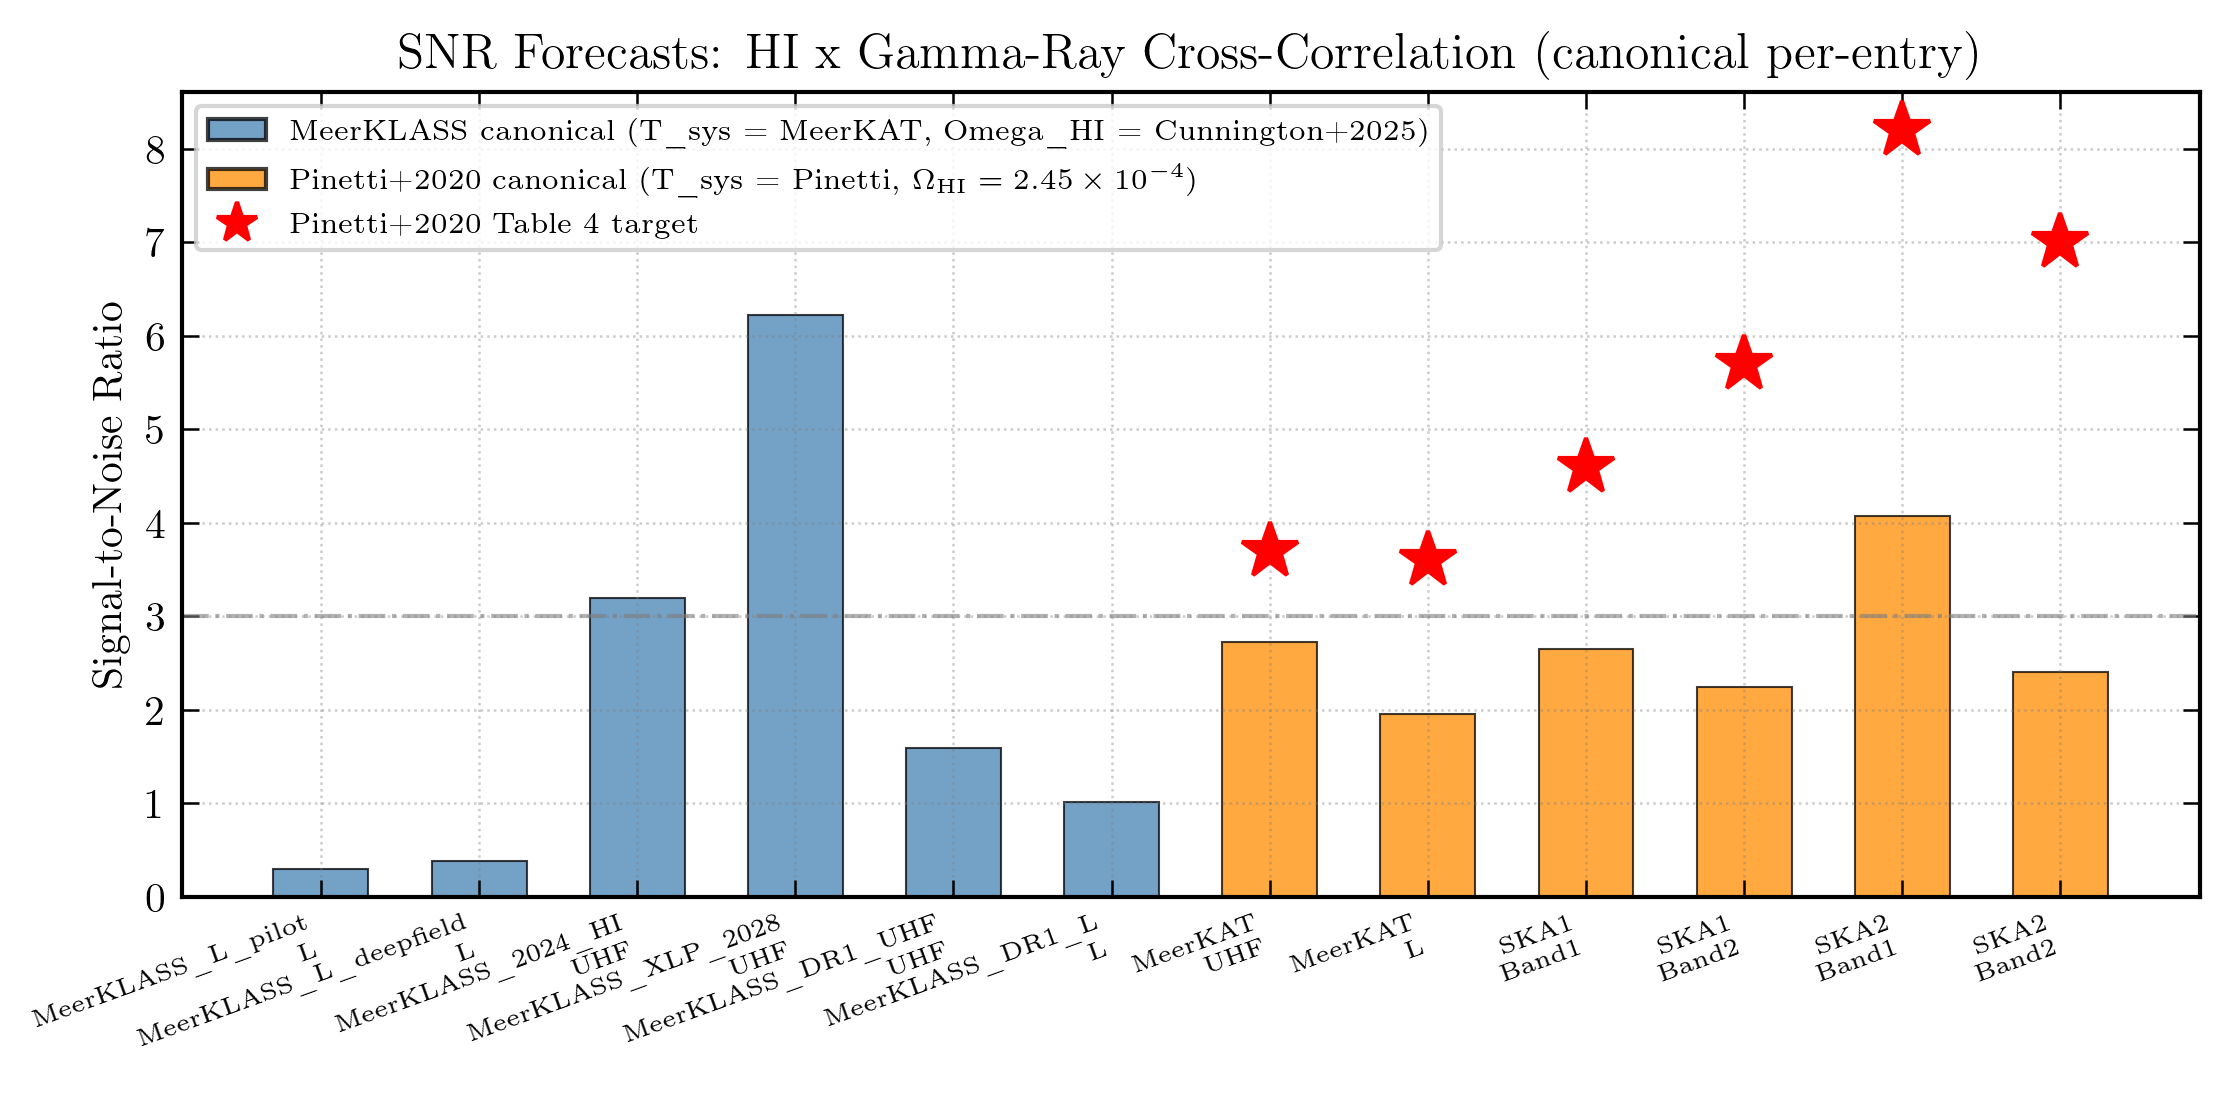

In [9]:
configs = [
    # MeerKAT HI single-dish baselines (canonical: T_sys_meerkat + Cunnington Omega_HI)
    ('MeerKLASS_L_pilot',     'L',     None),
    ('MeerKLASS_L_deepfield', 'L',     None),
    ('MeerKLASS_2024_HI',     'UHF',   None),
    ('MeerKLASS_XLP_2028',    'UHF',   None),
    # Interferometric continuum DR1s (commensal, not HI)
    ('MeerKLASS_DR1_UHF',     'UHF',   None),
    ('MeerKLASS_DR1_L',       'L',     None),
    # Pinetti+2020 forecast targets ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ Table 4, dish+interferometer column.
    # Pinetti+2020 forecasts use the canonical Pinetti settings
    # (T_sys_pinetti + fixed Omega_HI = 2.45e-4) for apples-to-apples comparison.
    # For SKA, Band 1 = high-z (0.35-3), Band 2 = low-z (0-0.5).
    ('MeerKAT',               'UHF',   3.7),
    ('MeerKAT',               'L',     3.6),
    ('SKA1',                  'Band1', 4.6),
    ('SKA1',                  'Band2', 5.7),
    ('SKA2',                  'Band1', 8.2),
    ('SKA2',                  'Band2', 7.0),
]

# Each entry now uses its CANONICAL convention via cfg.RADIO_TELESCOPES.
# - MeerKLASS_* entries: T_sys_model='meerkat' (Wang+2021 / MeerKLASS Collab. 2025
#   Eqs. 21-22, ~16 K L-band / ~17 K UHF) + default_hi_brightness='cunnington'
#   (Cunnington+2025 Eq. A5 polynomial Omega_HI + Eq. A3 polynomial b_HI).
# - MeerKAT/SKA1/SKA2 (Pinetti+2020 legacy): T_sys_model='pinetti' (Eq. 3.18
#   generic radio, ~32-35 K) + default_hi_brightness='fixed_omega'
#   (Pinetti's fixed Omega_HI = 2.45e-4).
# Passing hi_brightness=None makes compute_SNR read the canonical default
# from cfg.RADIO_TELESCOPES[telescope]['default_hi_brightness'].
snr_data = {}
for tel, bnd, target in configs:
    key = f'{tel}_{bnd}'
    print(f'  Computing canonical SNR for {tel} {bnd}...')
    snr = stats.compute_SNR(tel, bnd, ell_min=10, ell_max=500,
                            n_ell=25, n_z=10, n_M=15,
                            hi_brightness=None)  # canonical per-telescope
    snr_data[key] = {'snr': snr, 'target': target,
                     'mode': cfg.RADIO_TELESCOPES[tel]['default_hi_brightness'],
                     'tsys': cfg.RADIO_TELESCOPES[tel]['T_sys_model'],
                     'fsens': cfg.RADIO_TELESCOPES[tel]['default_unresolved_mode']}

fig, ax = sty.textwidth_figure(8)
labels = [t + '\n' + b for t, b, _ in configs]
x = np.arange(len(labels))

# Colour each bar by the canonical convention used
colors = []
for tel, bnd, _ in configs:
    mode = cfg.RADIO_TELESCOPES[tel]['default_hi_brightness']
    colors.append('steelblue' if mode == 'cunnington' else 'darkorange')

vals = [snr_data[f'{t}_{b}']['snr'] for t, b, _ in configs]
bars = ax.bar(x, vals, width=0.6, color=colors, alpha=sty.ALPHA_STANDARD,
              edgecolor='black', linewidth=0.5)

# Pinetti+2020 Table 4 red-star targets
targets = [tgt for _, _, tgt in configs]
for i, t in enumerate(targets):
    if t is not None:
        ax.plot(i, t, 'r*', ms=sty.MS_LARGE, zorder=5)

# Legend handles for the two canonical modes + Pinetti targets
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_handles = [
    Patch(facecolor='steelblue', alpha=sty.ALPHA_STANDARD, edgecolor='black',
          label='MeerKLASS canonical (T_sys = MeerKAT, Omega_HI = Cunnington+2025)'),
    Patch(facecolor='darkorange', alpha=sty.ALPHA_STANDARD, edgecolor='black',
          label=r'Pinetti+2020 canonical (T_sys = Pinetti, $\Omega_{\rm HI} = 2.45\times10^{-4}$)'),
    Line2D([0], [0], marker='*', color='r', linestyle='None', markersize=10,
           label='Pinetti+2020 Table 4 target'),
]
ax.legend(handles=legend_handles, fontsize=7, loc='upper left')

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=6, rotation=20, ha='right')
ax.set_ylabel('Signal-to-Noise Ratio')
ax.set_title('SNR Forecasts: HI x Gamma-Ray Cross-Correlation (canonical per-entry)')
ax.axhline(3.0, **sty.GUIDE_STYLE)
fig.tight_layout()

In [10]:
import pandas as pd

# Each entry shows the canonical SNR (using its per-telescope T_sys_model and
# default_hi_brightness from cfg.RADIO_TELESCOPES) plus its Pinetti+2020 target.
rows = []
for tel, bnd, target in configs:
    key = f'{tel}_{bnd}'
    d = snr_data[key]
    row = {
        'Telescope':       tel,
        'Band':            bnd,
        'T_sys model':     d['tsys'],
        'Omega_HI mode':   d['mode'],
        'F_sens model':    d['fsens'],
        'Canonical SNR':   d['snr'],
        'Pinetti target':  target,
    }
    rows.append(row)

df = pd.DataFrame(rows)
df

,Telescope,Band,T_sys model,Omega_HI mode,F_sens model,Canonical SNR,Pinetti target
0,MeerKLASS_L_pilot,L,meerkat,cunnington,4fgl_dr4_psf,0.297351,NaN
1,MeerKLASS_L_deepfield,L,meerkat,cunnington,4fgl_dr4_psf,0.380871,NaN
2,MeerKLASS_2024_HI,UHF,meerkat,cunnington,4fgl_dr4_psf,3.195190,NaN
3,MeerKLASS_XLP_2028,UHF,meerkat,cunnington,4fgl_dr4_psf,6.221362,NaN
4,MeerKLASS_DR1_UHF,UHF,meerkat,cunnington,4fgl_dr4_psf,1.595522,NaN
5,MeerKLASS_DR1_L,L,meerkat,cunnington,4fgl_dr4_psf,1.018047,NaN
6,MeerKAT,UHF,pinetti,fixed_omega,pinetti_constant,2.728681,3.7
7,MeerKAT,L,pinetti,fixed_omega,pinetti_constant,1.960626,3.6
8,SKA1,Band1,pinetti,fixed_omega,pinetti_constant,2.647514,4.6
9,SKA1,Band2,pinetti,fixed_omega,pinetti_constant,2.244609,5.7


## 8. DM Exclusion Curves

95% CL upper limits on the annihilation cross-section $\langle\sigma v\rangle$ as a function of DM mass $m_\chi$, for the $b\bar{b}$ channel. The dashed line marks the thermal relic value $3 \times 10^{-26}$ cm$^3$/s.

The optional computation below is set up for both HI brightness prescriptions: Padmanabhan halo-integral $\Omega_\mathrm{HI}(z)$ and fixed $\Omega_\mathrm{HI}=2.45\times10^{-4}$.

Loads from cache if available (~90s to recompute per telescope and HI prescription).


  Computing exclusion for SKA1 Band2 (canonical)...
  Computing exclusion for SKA2 Band2 (canonical)...


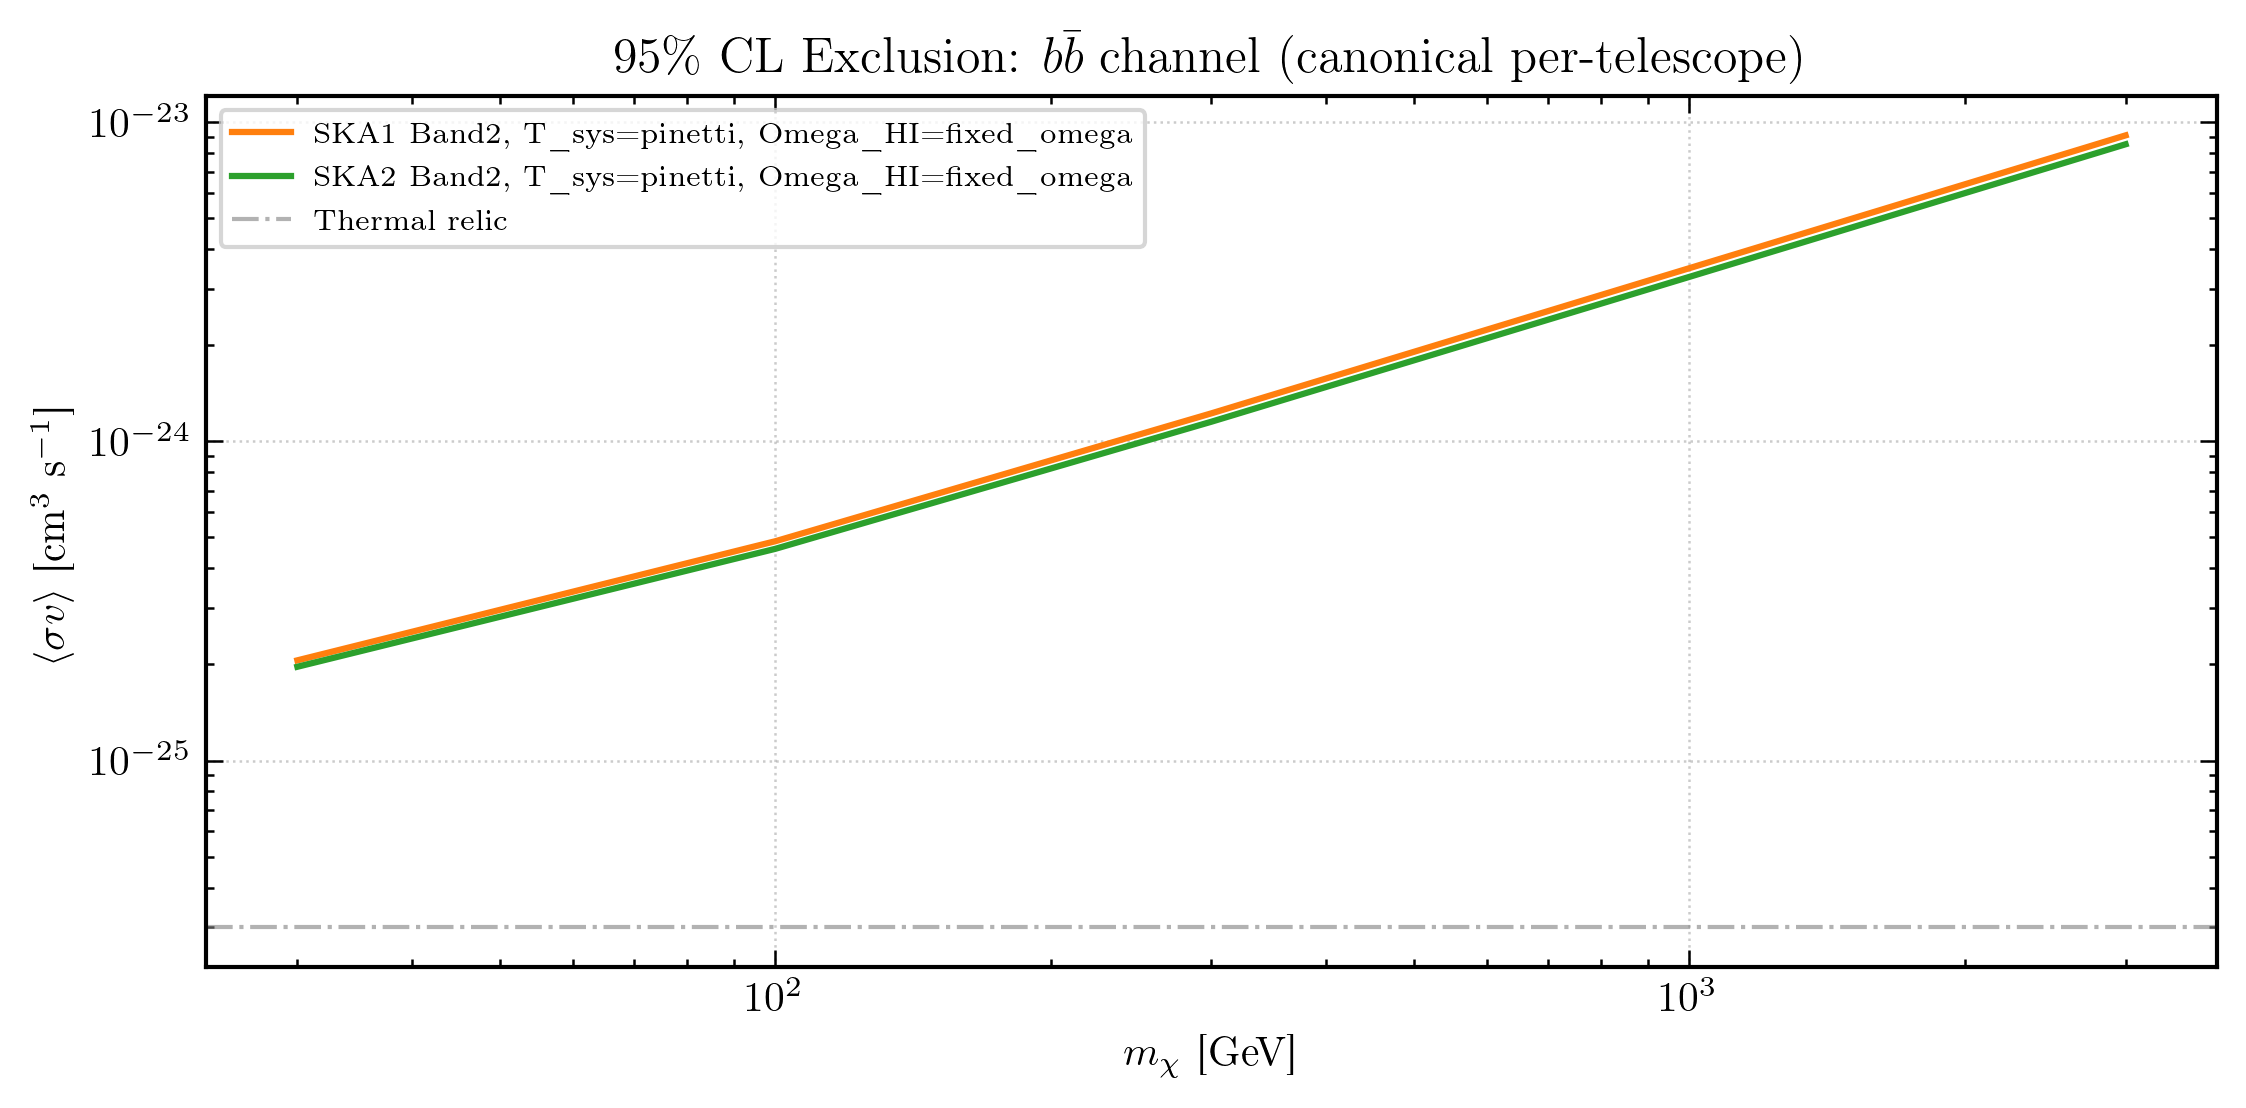

In [11]:
exc_data = {}
m_arr = np.array([30., 100., 300., 1000., 3000.])
# Each telescope uses its canonical hi_brightness mode (set per-entry in
# cfg.RADIO_TELESCOPES). For SKA1/SKA2 these are the Pinetti+2020 fixed-Omega_HI
# settings used by Pinetti's published forecasts. Compute one curve per telescope.
exc_configs = [
    ('SKA1', 'Band2', 'C1'),
    ('SKA2', 'Band2', 'C2'),
]
for tel, bnd, _ in exc_configs:
    key = f'{tel}_{bnd}'
    print(f'  Computing exclusion for {tel} {bnd} (canonical)...')
    m, sv = stats.exclusion_curve(tel, bnd, channel='bb', CL='95',
                                  m_chi_arr=m_arr, n_ell=10, n_z=6, n_M=8,
                                  hi_brightness=None)  # canonical per-telescope
    exc_data[key] = {'m_chi': m.tolist(), 'sigma_v': sv.tolist(),
                     'mode': cfg.RADIO_TELESCOPES[tel]['default_hi_brightness'],
                     'tsys': cfg.RADIO_TELESCOPES[tel]['T_sys_model']}

fig, ax = sty.textwidth_figure(8)
for tel, bnd, color in exc_configs:
    key = f'{tel}_{bnd}'
    d = exc_data[key]
    m = np.array(d['m_chi']); sv = np.array(d['sigma_v'])
    label = f'{tel} {bnd}, T_sys={d["tsys"]}, Omega_HI={d["mode"]}'
    ax.loglog(m, sv, color=color, ls='-', lw=sty.LW_STANDARD, label=label)

ax.axhline(cfg.SIGMA_V_THERMAL, **sty.GUIDE_STYLE, label='Thermal relic')
ax.set_xlabel(r'$m_\chi$ [GeV]')
ax.set_ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]')
ax.set_title(r'95\% CL Exclusion: $b\bar{b}$ channel (canonical per-telescope)')
ax.legend(fontsize=7)
fig.tight_layout()